# Controlled Matched-Provenance Monte Carlo Train/Test Evaluation

This notebook extends the controlled matched-star analyses in `analyze_comprehensive` by evaluating SPOC–TESSCut and QLP–TESSCut comparisons across repeated stratified random train/test splits.

## Evaluation design

The controlled matched datasets are substantially smaller than the full TESS dataset, particularly the SPOC–TESSCut sample. The adopted design therefore uses **repeated stratified Monte Carlo train/test evaluation** with a 70/30 split rather than dividing the matched samples into separate training, validation, and test subsets. The feature definitions, retained feature set, preprocessing procedure, Random Forest configuration, split ratio, number of iterations, and reported metrics are fixed independently of the repeated held-out results.

For every iteration:

- matched `VSXId` objects are divided into 70% training and 30% held-out test subsets;
- stratification preserves the variable-star family distribution as far as the sample permits;
- identical star-level assignments are used for the official product and TESSCut;
- the same Random Forest seed is used for both provenance models;
- all iterations and metrics are retained.

The notebook reports repeated predictive-performance differences, repeated permutation-importance stability, observational-feature ablation, paired per-class errors, and the manuscript tables and figures derived from these controlled analyses. The empirical split distributions quantify sensitivity to alternative train/test assignments and are not treated as independent-sample confidence intervals.


## 1. Imports and fixed analysis configuration

The analysis uses 100 repeated 70/30 stratified splits. The execution controls permit saved simulation and ablation outputs to be reloaded without refitting the models.


In [24]:
from pathlib import Path
import os
import json
import platform
import sys
import time

import numpy as np
import pandas as pd
import sklearn

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

Project_Root = Path(
    os.environ.get("Project_Root", "/data/projects/TESS_Research_RASTI_Publication")
)

# Inputs used by the controlled matched-provenance analysis.
MAIN_FEATURE_PATH = Project_Root / "data" / "processed" / "TESS_features.parquet"
SPOC_TESSCUT_FEATURE_PATH = (
    Project_Root / "data" / "processed" / "SPOC_TESSCut_features_QC.parquet"
)
QLP_TESSCUT_FEATURE_PATH = (
    Project_Root / "data" / "processed" / "QLP_TESSCut_features_QC.parquet"
)

OUTPUT_DIR = Project_Root / "results" / "controlled_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLUMN = "family"
STATUS_COLUMN = "FeatureStatus"
CORRELATION_THRESHOLD = 0.95

# Prespecified Monte Carlo design.
RUN_MONTE_CARLO = False
N_SPLITS = 100
TEST_SIZE = 0.30
BASE_RANDOM_SEED = 42
SPLIT_SEEDS = np.arange(BASE_RANDOM_SEED, BASE_RANDOM_SEED + N_SPLITS, dtype=int)

# Repeated permutation-importance design. These settings are prespecified before
# examining the repeated importance results. Twenty evenly spaced Monte Carlo
# splits balance stability assessment with computational cost.
RUN_REPEATED_PERMUTATION_IMPORTANCE = False
PERMUTATION_SPLIT_COUNT = 20
PERMUTATION_N_REPEATS = 10
PERMUTATION_SCORING = "balanced_accuracy"
# Keep this at 1 because Random Forest prediction already uses RF_N_JOBS cores.
# Parallelizing both levels would oversubscribe the same CPU cores.
PERMUTATION_N_JOBS = 1

if not 1 <= PERMUTATION_SPLIT_COUNT <= N_SPLITS:
    raise ValueError("PERMUTATION_SPLIT_COUNT must be between 1 and N_SPLITS.")
PERMUTATION_SPLIT_INDICES = np.linspace(
    0, N_SPLITS - 1, PERMUTATION_SPLIT_COUNT, dtype=int
)
PERMUTATION_SPLIT_SEEDS = [
    int(SPLIT_SEEDS[index]) for index in PERMUTATION_SPLIT_INDICES
]
PERMUTATION_SPLIT_SEED_SET = set(PERMUTATION_SPLIT_SEEDS)

# Use all available CPU cores inside each Random Forest fit. The outer Monte
# Carlo loop remains sequential to avoid oversubscribing the same cores and
# duplicating the matched datasets across concurrent jobs.
RF_N_JOBS = 24

# Fixed Random Forest configuration from Steps 21–23.
RF_PARAMETERS = {
    "n_estimators": 500,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "class_weight": "balanced_subsample",
    "n_jobs": RF_N_JOBS,
}

print(f"Output directory: {OUTPUT_DIR}")
print(f"Run Monte Carlo simulation: {RUN_MONTE_CARLO}")
print(f"Random Forest n_jobs: {RF_N_JOBS} (-1 means all available CPU cores)")
print(f"Monte Carlo iterations: {N_SPLITS}")
print(f"Run repeated permutation importance: {RUN_REPEATED_PERMUTATION_IMPORTANCE}")
print(f"Permutation-importance split count: {PERMUTATION_SPLIT_COUNT}")
print(f"Permutation repeats per feature/model: {PERMUTATION_N_REPEATS}")
print(f"Permutation scoring: {PERMUTATION_SCORING}")
print(f"Permutation split seeds: {PERMUTATION_SPLIT_SEEDS}")
print(f"Train/test fraction: {1.0 - TEST_SIZE:.0%}/{TEST_SIZE:.0%}")
print(f"Split seeds: {SPLIT_SEEDS[0]} through {SPLIT_SEEDS[-1]}")


Output directory: /data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2
Run Monte Carlo simulation: False
Random Forest n_jobs: 24 (-1 means all available CPU cores)
Monte Carlo iterations: 100
Run repeated permutation importance: False
Permutation-importance split count: 20
Permutation repeats per feature/model: 10
Permutation scoring: balanced_accuracy
Permutation split seeds: [42, 47, 52, 57, 62, 68, 73, 78, 83, 88, 94, 99, 104, 109, 114, 120, 125, 130, 135, 141]
Train/test fraction: 70%/30%
Split seeds: 42 through 141


## 2. Reconstruct the fixed predictor set

This section follows the reference notebook's feature exclusions and deterministic near-duplicate filter. The resulting predictor list is saved with the simulation outputs. It is determined once before the matched Monte Carlo experiment and is not changed in response to the repeated test results.


In [25]:
REDUNDANT_FEATURE_COLUMNS = {
    "FluxVariance",
    "FluxMean",
    "FluxP25",
    "FluxP75",
    "FluxMin",
    "FluxMax",
    "FluxP01",
    "FluxP99",
}

EXCLUDE_COLUMNS = {
    TARGET_COLUMN,
    STATUS_COLUMN,
    "FeatureError",
    "Name",
    "VSXId",
    "VSXType",
    "ticId",
    "bestTicId",
    "lightCurvePath",
    "rawLightCurvePath",
    "QualityLabel",
    "Provenance",
    "ProvenanceScore",
    *REDUNDANT_FEATURE_COLUMNS,
}


def build_fixed_feature_columns(feature_path):
    # Reproduce the reference notebook's fixed numeric predictor set.
    feature_df = pd.read_parquet(feature_path)
    if STATUS_COLUMN in feature_df.columns:
        model_df = feature_df[feature_df[STATUS_COLUMN] == "ok"].copy()
    else:
        model_df = feature_df.copy()

    model_df = model_df.dropna(subset=[TARGET_COLUMN]).copy()
    numeric_columns = model_df.select_dtypes(include=[np.number, bool]).columns.tolist()
    candidates = [column for column in numeric_columns if column not in EXCLUDE_COLUMNS]

    correlation_df = model_df[candidates].corr(method="spearman").abs()
    retained = []
    removed_records = []

    for candidate in candidates:
        correlated_retained = []
        for retained_feature in retained:
            value = correlation_df.loc[candidate, retained_feature]
            if pd.notna(value) and value > CORRELATION_THRESHOLD:
                correlated_retained.append((retained_feature, float(value)))

        if correlated_retained:
            kept_feature, correlation = max(
                correlated_retained,
                key=lambda item: item[1],
            )
            removed_records.append({
                "RemovedFeature": candidate,
                "RetainedFeature": kept_feature,
                "AbsoluteSpearmanCorrelation": correlation,
            })
        else:
            retained.append(candidate)

    removed_df = pd.DataFrame(removed_records)
    return retained, removed_df


FEATURE_COLUMNS, REMOVED_CORRELATED_FEATURES_DF = build_fixed_feature_columns(
    MAIN_FEATURE_PATH
)

assert "ProvenanceScore" not in FEATURE_COLUMNS
assert not REDUNDANT_FEATURE_COLUMNS.intersection(FEATURE_COLUMNS)

pd.DataFrame({"Feature": FEATURE_COLUMNS}).to_csv(
    OUTPUT_DIR / "fixed_feature_columns.csv",
    index=False,
)
REMOVED_CORRELATED_FEATURES_DF.to_csv(
    OUTPUT_DIR / "removed_correlated_features.csv",
    index=False,
)

print(f"Fixed predictor count: {len(FEATURE_COLUMNS)}")
display(pd.DataFrame({"Feature": FEATURE_COLUMNS}))


Fixed predictor count: 39


,Feature
0,QualityScore
1,OriginalFluxMedian
2,OriginalFluxStd
3,CadenceCount
4,TimeSpanDays
5,MedianCadenceDays
6,FluxStd
7,FluxMedian
8,FluxMad
9,FluxP05


## 3. Prepare controlled matched pairs

Exactly one official-product row and one TESSCut row are retained for each `VSXId`. Family labels must agree within a pair. Classes with fewer than two matched objects cannot support a stratified split and are excluded before simulation.


In [26]:
def normalize_provenance_label(value):
    text = str(value).strip().upper().replace("_", "").replace("-", "")
    if "SPOC" in text:
        return "SPOC"
    if "QLP" in text:
        return "QLP"
    if "TESSCUT" in text:
        return "TESSCut"
    return str(value).strip()


def resolve_provenance_column(df):
    for column in ["Provenance", "provenance", "Source", "source"]:
        if column in df.columns:
            return column
    raise KeyError("Could not find a provenance/source column.")


def prepare_matched_pair(feature_file, official_provenance):
    # Return one aligned official/TESSCut row per valid matched VSXId.
    df = pd.read_parquet(feature_file).copy()

    required = {"VSXId", TARGET_COLUMN}
    missing = sorted(required - set(df.columns))
    if missing:
        raise KeyError(f"Matched feature table is missing required columns: {missing}")

    provenance_column = resolve_provenance_column(df)
    df["_ProvenanceNormalized"] = df[provenance_column].map(
        normalize_provenance_label
    )
    df["VSXId"] = df["VSXId"].astype(str)
    df = df[
        df["_ProvenanceNormalized"].isin({official_provenance, "TESSCut"})
    ].copy()

    pair_counts = (
        df.groupby(["VSXId", "_ProvenanceNormalized"])
        .size()
        .unstack(fill_value=0)
    )
    for required_provenance in [official_provenance, "TESSCut"]:
        if required_provenance not in pair_counts.columns:
            pair_counts[required_provenance] = 0

    valid_ids = pair_counts.index[
        (pair_counts[official_provenance] == 1)
        & (pair_counts["TESSCut"] == 1)
    ]

    matched = df[df["VSXId"].isin(valid_ids)].copy()
    official_df = (
        matched[matched["_ProvenanceNormalized"] == official_provenance]
        .set_index("VSXId", drop=False)
        .sort_index()
    )
    tesscut_df = (
        matched[matched["_ProvenanceNormalized"] == "TESSCut"]
        .set_index("VSXId", drop=False)
        .sort_index()
    )

    common_ids = official_df.index.intersection(tesscut_df.index)
    official_df = official_df.loc[common_ids].copy()
    tesscut_df = tesscut_df.loc[common_ids].copy()

    mismatch = (
        official_df[TARGET_COLUMN].astype(str)
        != tesscut_df[TARGET_COLUMN].astype(str)
    )
    if mismatch.any():
        bad_ids = official_df.index[mismatch].tolist()
        raise ValueError(
            f"{official_provenance}–TESSCut family-label mismatches: "
            f"{len(bad_ids)}; examples={bad_ids[:10]}"
        )

    class_counts = official_df[TARGET_COLUMN].value_counts()
    keep_classes = class_counts[class_counts >= 2].index
    keep_ids = official_df.index[
        official_df[TARGET_COLUMN].isin(keep_classes)
    ]
    official_df = official_df.loc[keep_ids].copy()
    tesscut_df = tesscut_df.loc[keep_ids].copy()

    missing_official = sorted(set(FEATURE_COLUMNS) - set(official_df.columns))
    missing_tesscut = sorted(set(FEATURE_COLUMNS) - set(tesscut_df.columns))
    if missing_official or missing_tesscut:
        raise ValueError(
            "Matched comparison schema is incompatible with the fixed feature set. "
            f"Missing official={missing_official}; missing TESSCut={missing_tesscut}"
        )

    return official_df, tesscut_df, class_counts


SPOC_DF, SPOC_TESSCUT_DF, SPOC_CLASS_COUNTS = prepare_matched_pair(
    SPOC_TESSCUT_FEATURE_PATH,
    "SPOC",
)
QLP_DF, QLP_TESSCUT_DF, QLP_CLASS_COUNTS = prepare_matched_pair(
    QLP_TESSCUT_FEATURE_PATH,
    "QLP",
)

print(f"SPOC–TESSCut matched objects used: {len(SPOC_DF):,}")
display(SPOC_DF[TARGET_COLUMN].value_counts().rename("MatchedCount"))
print(f"QLP–TESSCut matched objects used: {len(QLP_DF):,}")
display(QLP_DF[TARGET_COLUMN].value_counts().rename("MatchedCount"))


SPOC–TESSCut matched objects used: 506


family
LONG_PERIOD        117
CV                 114
YSO                 92
CEPHEID             64
DSCT_SXPHE          51
ELLIPSOIDAL_ROT     29
XRAY                20
ECLIPSING           14
RRLYR                5
Name: MatchedCount, dtype: int64

QLP–TESSCut matched objects used: 1,355


family
LONG_PERIOD        487
CEPHEID            234
DSCT_SXPHE         211
ELLIPSOIDAL_ROT    151
YSO                133
ECLIPSING          110
RRLYR               17
XRAY                10
CV                   2
Name: MatchedCount, dtype: int64

## 4. Monte Carlo simulation functions

Each iteration creates one stratified object-level split and applies it unchanged to both provenances. Median imputation is fitted independently inside each training pipeline. No test observation is used to fit the imputer or classifier.

The notebook saves:

- one paired summary row per split and provenance comparison;
- long-format train/test performance metrics;
- per-family held-out precision, recall, F1, and support;
- prediction-level paired records for subsequent McNemar, bootstrap, or error analysis;
- Random Forest built-in feature importance for every split and provenance;
- repeated held-out permutation importance on 20 prespecified splits, including every raw permutation repeat;
- class counts and exact train/test object assignments for every iteration.

### Repeated permutation-importance design

Permutation importance is evaluated only on held-out test data and uses balanced accuracy, matching Steps 21–23. It is calculated for 20 prespecified, evenly spaced Monte Carlo split seeds with 10 permutations per feature and provenance model. Saving every raw repeat permits later assessment of within-model permutation noise, while the per-split summaries permit analysis of stability across alternative train/test assignments.


In [27]:
def make_rf_pipeline(random_state):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            random_state=int(random_state),
            **RF_PARAMETERS,
        )),
    ])


def fit_one_provenance(source_df, train_ids, test_ids, random_state):
    train_df = source_df.loc[train_ids]
    test_df = source_df.loc[test_ids]

    x_train = train_df[FEATURE_COLUMNS]
    y_train = train_df[TARGET_COLUMN]
    x_test = test_df[FEATURE_COLUMNS]
    y_test = test_df[TARGET_COLUMN]

    model = make_rf_pipeline(random_state)
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    metrics = {
        "train_accuracy": accuracy_score(y_train, train_pred),
        "train_balanced_accuracy": balanced_accuracy_score(y_train, train_pred),
        "train_macro_f1": f1_score(y_train, train_pred, average="macro", zero_division=0),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "test_macro_f1": f1_score(y_test, test_pred, average="macro", zero_division=0),
    }

    estimator = model.named_steps["model"]
    importance_df = pd.DataFrame({
        "Feature": FEATURE_COLUMNS,
        "RFImportance": estimator.feature_importances_,
    })

    return {
        "model": model,
        "x_train": x_train,
        "x_test": x_test,
        "y_train": y_train,
        "y_test": y_test,
        "train_pred": train_pred,
        "test_pred": test_pred,
        "metrics": metrics,
        "importance_df": importance_df,
    }


def calculate_permutation_importance_records(
    result,
    comparison_name,
    official_provenance,
    provenance,
    iteration,
    split_seed,
):
    """Return per-feature summary and raw repeat records for one held-out model."""
    permutation_result = permutation_importance(
        result["model"],
        result["x_test"],
        result["y_test"],
        scoring=PERMUTATION_SCORING,
        n_repeats=PERMUTATION_N_REPEATS,
        random_state=int(split_seed),
        n_jobs=PERMUTATION_N_JOBS,
    )

    summary_df = pd.DataFrame({
        "Feature": FEATURE_COLUMNS,
        "PermutationImportanceMean": permutation_result.importances_mean,
        "PermutationImportanceStd": permutation_result.importances_std,
    })
    summary_df["PermutationImportanceRank"] = summary_df[
        "PermutationImportanceMean"
    ].rank(method="average", ascending=False)
    summary_df.insert(0, "Provenance", provenance)
    summary_df.insert(0, "SplitSeed", int(split_seed))
    summary_df.insert(0, "Iteration", int(iteration))
    summary_df.insert(0, "OfficialProvenance", official_provenance)
    summary_df.insert(0, "Comparison", comparison_name)

    raw_rows = []
    for feature_index, feature in enumerate(FEATURE_COLUMNS):
        for repeat_index, importance_value in enumerate(
            permutation_result.importances[feature_index], start=1
        ):
            raw_rows.append({
                "Comparison": comparison_name,
                "OfficialProvenance": official_provenance,
                "Iteration": int(iteration),
                "SplitSeed": int(split_seed),
                "Provenance": provenance,
                "Feature": feature,
                "PermutationRepeat": int(repeat_index),
                "PermutationImportance": float(importance_value),
                "Scoring": PERMUTATION_SCORING,
            })

    return summary_df, pd.DataFrame(raw_rows)


def run_monte_carlo_pair(
    official_df,
    tesscut_df,
    official_provenance,
    comparison_name,
    split_seeds,
    test_size=0.30,
):
    ids = official_df.index.to_numpy()
    labels = official_df.loc[ids, TARGET_COLUMN]

    paired_summary_rows = []
    performance_rows = []
    family_rows = []
    prediction_rows = []
    importance_rows = []
    assignment_rows = []
    permutation_summary_rows = []
    permutation_repeat_rows = []

    started = time.time()
    for iteration, seed in enumerate(split_seeds, start=1):
        train_ids, test_ids = train_test_split(
            ids,
            test_size=test_size,
            stratify=labels,
            random_state=int(seed),
        )
        train_ids = sorted(train_ids)
        test_ids = sorted(test_ids)

        # The same RF seed within the pair prevents arbitrary asymmetric model seeds.
        official_result = fit_one_provenance(
            official_df,
            train_ids,
            test_ids,
            random_state=seed,
        )
        tesscut_result = fit_one_provenance(
            tesscut_df,
            train_ids,
            test_ids,
            random_state=seed,
        )

        official_metrics = official_result["metrics"]
        tesscut_metrics = tesscut_result["metrics"]

        paired_summary_rows.append({
            "Comparison": comparison_name,
            "OfficialProvenance": official_provenance,
            "Iteration": iteration,
            "SplitSeed": int(seed),
            "TrainCount": len(train_ids),
            "TestCount": len(test_ids),
            "OfficialTestAccuracy": official_metrics["test_accuracy"],
            "TESSCutTestAccuracy": tesscut_metrics["test_accuracy"],
            "DeltaTestAccuracy": (
                official_metrics["test_accuracy"] - tesscut_metrics["test_accuracy"]
            ),
            "OfficialTestBalancedAccuracy": official_metrics["test_balanced_accuracy"],
            "TESSCutTestBalancedAccuracy": tesscut_metrics["test_balanced_accuracy"],
            "DeltaTestBalancedAccuracy": (
                official_metrics["test_balanced_accuracy"]
                - tesscut_metrics["test_balanced_accuracy"]
            ),
            "OfficialTestMacroF1": official_metrics["test_macro_f1"],
            "TESSCutTestMacroF1": tesscut_metrics["test_macro_f1"],
            "DeltaTestMacroF1": (
                official_metrics["test_macro_f1"] - tesscut_metrics["test_macro_f1"]
            ),
        })

        for provenance, result in [
            (official_provenance, official_result),
            ("TESSCut", tesscut_result),
        ]:
            for split_name in ["train", "test"]:
                performance_rows.append({
                    "Comparison": comparison_name,
                    "OfficialProvenance": official_provenance,
                    "Iteration": iteration,
                    "SplitSeed": int(seed),
                    "Provenance": provenance,
                    "Split": split_name,
                    "SampleCount": len(result[f"y_{split_name}"]),
                    "Accuracy": result["metrics"][f"{split_name}_accuracy"],
                    "BalancedAccuracy": result["metrics"][f"{split_name}_balanced_accuracy"],
                    "MacroF1": result["metrics"][f"{split_name}_macro_f1"],
                })

            report = classification_report(
                result["y_test"],
                result["test_pred"],
                output_dict=True,
                zero_division=0,
            )
            for family in sorted(result["y_test"].unique()):
                values = report.get(family, {})
                family_rows.append({
                    "Comparison": comparison_name,
                    "OfficialProvenance": official_provenance,
                    "Iteration": iteration,
                    "SplitSeed": int(seed),
                    "Provenance": provenance,
                    "Family": family,
                    "Precision": values.get("precision", np.nan),
                    "Recall": values.get("recall", np.nan),
                    "F1Score": values.get("f1-score", np.nan),
                    "Support": values.get("support", np.nan),
                })

            importance = result["importance_df"].copy()
            importance.insert(0, "Provenance", provenance)
            importance.insert(0, "SplitSeed", int(seed))
            importance.insert(0, "Iteration", iteration)
            importance.insert(0, "OfficialProvenance", official_provenance)
            importance.insert(0, "Comparison", comparison_name)
            importance_rows.extend(importance.to_dict("records"))

            if (
                RUN_REPEATED_PERMUTATION_IMPORTANCE
                and int(seed) in PERMUTATION_SPLIT_SEED_SET
            ):
                permutation_summary, permutation_repeats = (
                    calculate_permutation_importance_records(
                        result=result,
                        comparison_name=comparison_name,
                        official_provenance=official_provenance,
                        provenance=provenance,
                        iteration=iteration,
                        split_seed=seed,
                    )
                )
                permutation_summary_rows.extend(
                    permutation_summary.to_dict("records")
                )
                permutation_repeat_rows.extend(
                    permutation_repeats.to_dict("records")
                )

        y_test = official_result["y_test"].loc[test_ids]
        for position, vsx_id in enumerate(test_ids):
            official_prediction = official_result["test_pred"][position]
            tesscut_prediction = tesscut_result["test_pred"][position]
            actual = y_test.loc[vsx_id]
            prediction_rows.append({
                "Comparison": comparison_name,
                "OfficialProvenance": official_provenance,
                "Iteration": iteration,
                "SplitSeed": int(seed),
                "VSXId": vsx_id,
                "ActualFamily": actual,
                "OfficialPrediction": official_prediction,
                "TESSCutPrediction": tesscut_prediction,
                "OfficialCorrect": bool(official_prediction == actual),
                "TESSCutCorrect": bool(tesscut_prediction == actual),
            })

        assignment_rows.extend([
            {
                "Comparison": comparison_name,
                "Iteration": iteration,
                "SplitSeed": int(seed),
                "VSXId": vsx_id,
                "Assignment": "train",
            }
            for vsx_id in train_ids
        ])
        assignment_rows.extend([
            {
                "Comparison": comparison_name,
                "Iteration": iteration,
                "SplitSeed": int(seed),
                "VSXId": vsx_id,
                "Assignment": "test",
            }
            for vsx_id in test_ids
        ])

        if iteration == 1 or iteration % 10 == 0 or iteration == len(split_seeds):
            elapsed = time.time() - started
            print(
                f"{comparison_name}: completed {iteration}/{len(split_seeds)} "
                f"iterations ({elapsed:.1f} seconds elapsed)"
            )

    return {
        "paired_summary": pd.DataFrame(paired_summary_rows),
        "performance": pd.DataFrame(performance_rows),
        "family_metrics": pd.DataFrame(family_rows),
        "predictions": pd.DataFrame(prediction_rows),
        "rf_importance": pd.DataFrame(importance_rows),
        "assignments": pd.DataFrame(assignment_rows),
        "permutation_importance_summary": pd.DataFrame(permutation_summary_rows),
        "permutation_importance_repeats": pd.DataFrame(permutation_repeat_rows),
    }


## 5. Run both controlled matched-provenance simulations

`RUN_MONTE_CARLO` controls whether the 100 matched-provenance Random Forest simulations are fitted or previously saved results are loaded. Each Random Forest uses `RF_N_JOBS` workers, while the outer Monte Carlo loop remains sequential to avoid nested parallelism and excessive memory use.

`RUN_REPEATED_PERMUTATION_IMPORTANCE` controls held-out permutation importance for the 20 prespecified split seeds. Permutation importance uses one outer job because prediction within each fitted Random Forest already uses `RF_N_JOBS` workers.


In [28]:
if RUN_MONTE_CARLO:
    SPOC_MONTE_CARLO_RESULTS = run_monte_carlo_pair(
        official_df=SPOC_DF,
        tesscut_df=SPOC_TESSCUT_DF,
        official_provenance="SPOC",
        comparison_name="SPOC_vs_TESSCut",
        split_seeds=SPLIT_SEEDS,
        test_size=TEST_SIZE,
    )

    QLP_MONTE_CARLO_RESULTS = run_monte_carlo_pair(
        official_df=QLP_DF,
        tesscut_df=QLP_TESSCUT_DF,
        official_provenance="QLP",
        comparison_name="QLP_vs_TESSCut",
        split_seeds=SPLIT_SEEDS,
        test_size=TEST_SIZE,
    )

    print("Both Monte Carlo simulations completed.")
else:
    SPOC_MONTE_CARLO_RESULTS = None
    QLP_MONTE_CARLO_RESULTS = None
    print(
        "RUN_MONTE_CARLO is False: bypassed all model fitting. "
        "Previously saved outputs will be loaded in Section 6."
    )


RUN_MONTE_CARLO is False: bypassed all model fitting. Previously saved outputs will be loaded in Section 6.


## 6. Save raw simulation results

The following cell combines and saves the raw outputs needed for the later conclusion analysis. It does not calculate confidence intervals, significance tests, aggregate conclusions, or preferred interpretations.


In [29]:
RESULT_KEYS = [
    "paired_summary",
    "performance",
    "family_metrics",
    "predictions",
    "rf_importance",
    "assignments",
    "permutation_importance_summary",
    "permutation_importance_repeats",
]

output_files = {
    "paired_summary": OUTPUT_DIR / "monte_carlo_paired_split_summary.csv",
    "performance": OUTPUT_DIR / "monte_carlo_performance_long.csv",
    "family_metrics": OUTPUT_DIR / "monte_carlo_family_test_metrics.csv",
    "predictions": OUTPUT_DIR / "monte_carlo_paired_test_predictions.parquet",
    "rf_importance": OUTPUT_DIR / "monte_carlo_rf_feature_importance.parquet",
    "assignments": OUTPUT_DIR / "monte_carlo_split_assignments.parquet",
    "permutation_importance_summary": OUTPUT_DIR / "monte_carlo_permutation_importance_summary.csv",
    "permutation_importance_repeats": OUTPUT_DIR / "monte_carlo_permutation_importance_repeats.csv",
}
manifest_path = OUTPUT_DIR / "monte_carlo_run_manifest.json"

if RUN_MONTE_CARLO:
    combined_results = {}
    for key in RESULT_KEYS:
        combined_results[key] = pd.concat(
            [SPOC_MONTE_CARLO_RESULTS[key], QLP_MONTE_CARLO_RESULTS[key]],
            ignore_index=True,
        )

    combined_results["paired_summary"].to_csv(output_files["paired_summary"], index=False)
    combined_results["performance"].to_csv(output_files["performance"], index=False)
    combined_results["family_metrics"].to_csv(output_files["family_metrics"], index=False)
    combined_results["predictions"].to_parquet(output_files["predictions"], index=False)
    combined_results["rf_importance"].to_parquet(output_files["rf_importance"], index=False)
    combined_results["assignments"].to_parquet(output_files["assignments"], index=False)
    combined_results["permutation_importance_summary"].to_csv(
        output_files["permutation_importance_summary"], index=False
    )
    combined_results["permutation_importance_repeats"].to_csv(
        output_files["permutation_importance_repeats"], index=False
    )

    run_manifest = {
        "analysis_name": "controlled_analysis_monte_carlo",
        "method": "repeated stratified Monte Carlo train/test evaluation",
        "n_splits": int(N_SPLITS),
        "test_size": float(TEST_SIZE),
        "base_random_seed": int(BASE_RANDOM_SEED),
        "split_seeds": [int(seed) for seed in SPLIT_SEEDS],
        "target_column": TARGET_COLUMN,
        "feature_count": len(FEATURE_COLUMNS),
        "feature_columns": FEATURE_COLUMNS,
        "correlation_threshold": float(CORRELATION_THRESHOLD),
        "rf_n_jobs": int(RF_N_JOBS),
        "rf_parameters": RF_PARAMETERS,
        "repeated_permutation_importance": {
            "enabled": bool(RUN_REPEATED_PERMUTATION_IMPORTANCE),
            "split_count": int(PERMUTATION_SPLIT_COUNT),
            "split_seeds": PERMUTATION_SPLIT_SEEDS,
            "n_repeats": int(PERMUTATION_N_REPEATS),
            "scoring": PERMUTATION_SCORING,
            "n_jobs": int(PERMUTATION_N_JOBS),
        },
        "input_files": {
            "main_features": str(MAIN_FEATURE_PATH),
            "spoc_tesscut_features": str(SPOC_TESSCUT_FEATURE_PATH),
            "qlp_tesscut_features": str(QLP_TESSCUT_FEATURE_PATH),
        },
        "matched_counts": {
            "SPOC_vs_TESSCut": int(len(SPOC_DF)),
            "QLP_vs_TESSCut": int(len(QLP_DF)),
        },
        "software": {
            "python": sys.version,
            "platform": platform.platform(),
            "numpy": np.__version__,
            "pandas": pd.__version__,
            "scikit_learn": sklearn.__version__,
        },
        "output_files": {key: str(path) for key, path in output_files.items()},
    }
    manifest_path.write_text(json.dumps(run_manifest, indent=2), encoding="utf-8")

    print("Saved simulation outputs:")
    for path in [*output_files.values(), manifest_path]:
        print(path)
else:
    missing_outputs = [
        path for path in [*output_files.values(), manifest_path]
        if not path.exists()
    ]
    if missing_outputs:
        raise FileNotFoundError(
            "RUN_MONTE_CARLO is False, but saved outputs are missing: "
            + ", ".join(str(path) for path in missing_outputs)
            + ". Run once with RUN_MONTE_CARLO = True before using bypass mode."
        )

    combined_results = {
        "paired_summary": pd.read_csv(output_files["paired_summary"]),
        "performance": pd.read_csv(output_files["performance"]),
        "family_metrics": pd.read_csv(output_files["family_metrics"]),
        "predictions": pd.read_parquet(output_files["predictions"]),
        "rf_importance": pd.read_parquet(output_files["rf_importance"]),
        "assignments": pd.read_parquet(output_files["assignments"]),
        "permutation_importance_summary": pd.read_csv(
            output_files["permutation_importance_summary"]
        ),
        "permutation_importance_repeats": pd.read_csv(
            output_files["permutation_importance_repeats"]
        ),
    }
    run_manifest = json.loads(manifest_path.read_text(encoding="utf-8"))

    print("Loaded previously saved simulation outputs; no models were fitted.")
    for path in [*output_files.values(), manifest_path]:
        print(path)


Loaded previously saved simulation outputs; no models were fitted.
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/monte_carlo_paired_split_summary.csv
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/monte_carlo_performance_long.csv
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/monte_carlo_family_test_metrics.csv
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/monte_carlo_paired_test_predictions.parquet
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/monte_carlo_rf_feature_importance.parquet
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/monte_carlo_split_assignments.parquet
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/monte_carlo_permutation_importance_summary.csv
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/monte_carlo_permutation_importance_repeats.csv
/data/projects/TESS-research/summ

## 7. Mechanical output verification

This section verifies that the required number of iterations and raw records were saved before the aggregate analyses are computed.


In [30]:
completed_n_splits = int(run_manifest["n_splits"])
expected_summary_rows = completed_n_splits * 2
actual_summary_rows = len(combined_results["paired_summary"])
assert actual_summary_rows == expected_summary_rows, (
    f"Expected {expected_summary_rows} paired summary rows, "
    f"found {actual_summary_rows}."
)

for comparison in ["SPOC_vs_TESSCut", "QLP_vs_TESSCut"]:
    subset = combined_results["paired_summary"]
    subset = subset[subset["Comparison"] == comparison]
    assert subset["Iteration"].nunique() == completed_n_splits
    assert subset["SplitSeed"].nunique() == completed_n_splits

for key, path in output_files.items():
    assert path.exists(), f"Missing expected output: {path}"
assert manifest_path.exists(), f"Missing expected output: {manifest_path}"


permutation_settings = run_manifest.get("repeated_permutation_importance", {})
if permutation_settings.get("enabled", False):
    expected_permutation_summary_rows = (
        2  # provenance comparisons
        * int(permutation_settings["split_count"])
        * 2  # official product and TESSCut
        * int(run_manifest["feature_count"])
    )
    expected_permutation_repeat_rows = (
        expected_permutation_summary_rows
        * int(permutation_settings["n_repeats"])
    )
    assert len(combined_results["permutation_importance_summary"]) == (
        expected_permutation_summary_rows
    )
    assert len(combined_results["permutation_importance_repeats"]) == (
        expected_permutation_repeat_rows
    )

verification_df = pd.DataFrame([
    {
        "Output": key,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Path": str(output_files[key]),
    }
    for key, df in combined_results.items()
])

print("Mechanical verification passed. Raw results are ready for separate analysis.")
display(verification_df)


Mechanical verification passed. Raw results are ready for separate analysis.


,Output,Rows,Columns,Path
0,paired_summary,200,15,/data/projects/TESS-research/summary/controlle...
1,performance,800,10,/data/projects/TESS-research/summary/controlle...
2,family_metrics,3600,10,/data/projects/TESS-research/summary/controlle...
3,predictions,55900,10,/data/projects/TESS-research/summary/controlle...
4,rf_importance,15600,7,/data/projects/TESS-research/summary/controlle...
5,assignments,186100,5,/data/projects/TESS-research/summary/controlle...
6,permutation_importance_summary,3120,9,/data/projects/TESS-research/summary/controlle...
7,permutation_importance_repeats,31200,9,/data/projects/TESS-research/summary/controlle...


## 8. Conclusion analysis

This section analyzes the saved Monte Carlo outputs. It works in bypass mode (`RUN_MONTE_CARLO = False`) and therefore does not refit any models. The 2.5th–97.5th percentile ranges below describe sensitivity across the repeated stratified splits; they are empirical split distributions, not confidence intervals from independent samples.


In [31]:
paired = combined_results["paired_summary"].copy()

metric_labels = {
    "DeltaTestAccuracy": "Accuracy",
    "DeltaTestBalancedAccuracy": "Balanced accuracy",
    "DeltaTestMacroF1": "Macro F1",
}

performance_rows = []
for comparison, group in paired.groupby("Comparison", sort=False):
    for column, label in metric_labels.items():
        values = group[column].dropna()
        performance_rows.append({
            "Comparison": comparison,
            "Metric": label,
            "Mean official-minus-TESSCut delta": values.mean(),
            "Median delta": values.median(),
            "2.5th percentile": values.quantile(0.025),
            "97.5th percentile": values.quantile(0.975),
            "Official product wins": int((values > 0).sum()),
            "Splits": int(len(values)),
        })

performance_conclusion = pd.DataFrame(performance_rows)
display(performance_conclusion.style.format({
    "Mean official-minus-TESSCut delta": "{:+.4f}",
    "Median delta": "{:+.4f}",
    "2.5th percentile": "{:+.4f}",
    "97.5th percentile": "{:+.4f}",
}))

permutation = combined_results["permutation_importance_summary"].copy()
importance_rows = []

for comparison, comparison_df in permutation.groupby("Comparison", sort=False):
    official_name = comparison_df["OfficialProvenance"].iloc[0]
    split_rows = []
    for split_seed, split_df in comparison_df.groupby("SplitSeed", sort=True):
        official = split_df[split_df["Provenance"] == official_name][
            ["Feature", "PermutationImportanceMean"]
        ].rename(columns={"PermutationImportanceMean": "OfficialImportance"})
        tesscut = split_df[split_df["Provenance"] == "TESSCut"][
            ["Feature", "PermutationImportanceMean"]
        ].rename(columns={"PermutationImportanceMean": "TESSCutImportance"})
        merged = official.merge(tesscut, on="Feature", how="inner")

        rho = merged["OfficialImportance"].corr(
            merged["TESSCutImportance"], method="spearman"
        )
        official_top5 = set(merged.nlargest(5, "OfficialImportance")["Feature"])
        tesscut_top5 = set(merged.nlargest(5, "TESSCutImportance")["Feature"])
        official_top10 = set(merged.nlargest(10, "OfficialImportance")["Feature"])
        tesscut_top10 = set(merged.nlargest(10, "TESSCutImportance")["Feature"])
        split_rows.append({
            "rho": rho,
            "top5_overlap": len(official_top5 & tesscut_top5),
            "top10_overlap": len(official_top10 & tesscut_top10),
        })

    split_summary = pd.DataFrame(split_rows)
    importance_rows.append({
        "Comparison": comparison,
        "Permutation splits": len(split_summary),
        "Mean cross-provenance Spearman rho": split_summary["rho"].mean(),
        "Median cross-provenance Spearman rho": split_summary["rho"].median(),
        "Minimum rho": split_summary["rho"].min(),
        "Maximum rho": split_summary["rho"].max(),
        "Mean top-5 overlap": split_summary["top5_overlap"].mean(),
        "Mean top-10 overlap": split_summary["top10_overlap"].mean(),
    })

importance_conclusion = pd.DataFrame(importance_rows)
display(importance_conclusion.style.format({
    "Mean cross-provenance Spearman rho": "{:.3f}",
    "Median cross-provenance Spearman rho": "{:.3f}",
    "Minimum rho": "{:.3f}",
    "Maximum rho": "{:.3f}",
    "Mean top-5 overlap": "{:.2f}",
    "Mean top-10 overlap": "{:.2f}",
}))


,Comparison,Metric,Mean official-minus-TESSCut delta,Median delta,2.5th percentile,97.5th percentile,Official product wins,Splits
0,SPOC_vs_TESSCut,Accuracy,+0.1366,+0.1349,+0.0686,+0.2109,100,100
1,SPOC_vs_TESSCut,Balanced accuracy,+0.2135,+0.2111,+0.1025,+0.3068,100,100
2,SPOC_vs_TESSCut,Macro F1,+0.2389,+0.2410,+0.1138,+0.3389,100,100
3,QLP_vs_TESSCut,Accuracy,+0.1507,+0.1523,+0.1055,+0.1905,100,100
4,QLP_vs_TESSCut,Balanced accuracy,+0.1625,+0.1637,+0.1115,+0.2142,100,100
5,QLP_vs_TESSCut,Macro F1,+0.1856,+0.1868,+0.1306,+0.2291,100,100


,Comparison,Permutation splits,Mean cross-provenance Spearman rho,Median cross-provenance Spearman rho,Minimum rho,Maximum rho,Mean top-5 overlap,Mean top-10 overlap
0,SPOC_vs_TESSCut,20,0.099,0.082,-0.220,0.369,0.90,3.45
1,QLP_vs_TESSCut,20,0.394,0.423,0.093,0.628,1.75,5.00


### Conclusion

The repeated matched-star evaluation supports both central claims, although with different strengths.

1. **Provenance affects downstream Random Forest performance.** Across all 100 repeated stratified splits, the official SPOC and QLP products outperform their matched TESSCut versions in test accuracy, balanced accuracy, and macro F1. The effect is consistently positive rather than being an artifact of one favorable train/test split. This is the strongest conclusion of the controlled experiment.

2. **Provenance affects the model's feature-dependence profile, with important qualification.** Repeated held-out permutation importance shows low cross-provenance agreement for SPOC versus TESSCut and moderate agreement for QLP versus TESSCut. Thus, light-curve provenance is associated with changes in which measurements the fitted classifier relies upon. However, importance rankings also vary across train/test splits, so individual rank changes should not automatically be attributed entirely to provenance. Interpretation should emphasize aggregate profile differences and features whose shifts persist across repeated splits.

Overall, the results demonstrate that TESS light-curve products are not interchangeable inputs to this classification pipeline. Provenance has a robust effect on predictive performance and a more heterogeneous—but still meaningful—association with model interpretation. These conclusions apply to the matched samples, extraction procedures, feature set, and Random Forest design evaluated here; they do not establish that every individual feature shift is caused solely by provenance.


## 9. Ablation of provenance-associated observational features

### Prespecified design

This sensitivity analysis measures whether the matched-provenance performance gaps persist after removing predictors that directly encode product construction, temporal sampling, coverage, quality screening, or original flux scale:

- `QualityScore`
- `CadenceCount`
- `TimeSpanDays`
- `MedianCadenceDays`
- `OriginalFluxMedian`
- `OriginalFluxStd`

The ablated models use the same matched objects, class labels, 100 split seeds, 70/30 stratified train/test assignments, preprocessing pipeline, and Random Forest hyperparameters as the full-feature models. Full-versus-ablated changes are therefore paired by provenance comparison and split seed. Permutation importance is not recomputed in this section.

`RUN_METADATA_ABLATION` controls whether the ablated models are fitted or their previously saved outputs are loaded.


In [32]:
# Independent control for this appended sensitivity analysis.
RUN_METADATA_ABLATION = False

METADATA_LIKE_FEATURE_CANDIDATES = [
    "QualityScore",
    "CadenceCount",
    "TimeSpanDays",
    "MedianCadenceDays",
    "OriginalFluxMedian",
    "OriginalFluxStd",
]

FULL_FEATURE_COLUMNS = list(FEATURE_COLUMNS)
METADATA_LIKE_FEATURES_REMOVED = [
    feature for feature in METADATA_LIKE_FEATURE_CANDIDATES
    if feature in FULL_FEATURE_COLUMNS
]
ABLATED_FEATURE_COLUMNS = [
    feature for feature in FULL_FEATURE_COLUMNS
    if feature not in METADATA_LIKE_FEATURES_REMOVED
]

if not METADATA_LIKE_FEATURES_REMOVED:
    raise ValueError("None of the prespecified metadata-like features are present.")
if not ABLATED_FEATURE_COLUMNS:
    raise ValueError("Metadata ablation removed every predictor.")

print(f"Run metadata-like feature ablation: {RUN_METADATA_ABLATION}")
print(f"Full feature count: {len(FULL_FEATURE_COLUMNS)}")
print(f"Ablated feature count: {len(ABLATED_FEATURE_COLUMNS)}")
print("Removed features:", METADATA_LIKE_FEATURES_REMOVED)
display(pd.DataFrame({"AblatedFeature": METADATA_LIKE_FEATURES_REMOVED}))


Run metadata-like feature ablation: False
Full feature count: 39
Ablated feature count: 33
Removed features: ['QualityScore', 'CadenceCount', 'TimeSpanDays', 'MedianCadenceDays', 'OriginalFluxMedian', 'OriginalFluxStd']


,AblatedFeature
0,QualityScore
1,CadenceCount
2,TimeSpanDays
3,MedianCadenceDays
4,OriginalFluxMedian
5,OriginalFluxStd


In [33]:
ABLATION_OUTPUT_FILES = {
    "paired_summary": OUTPUT_DIR / "metadata_ablation_paired_split_summary.csv",
    "performance": OUTPUT_DIR / "metadata_ablation_performance_long.csv",
    "family_metrics": OUTPUT_DIR / "metadata_ablation_family_test_metrics.csv",
    "predictions": OUTPUT_DIR / "metadata_ablation_paired_test_predictions.parquet",
    "rf_importance": OUTPUT_DIR / "metadata_ablation_rf_feature_importance.parquet",
    "assignments": OUTPUT_DIR / "metadata_ablation_split_assignments.parquet",
}
ABLATION_FEATURE_FILE = OUTPUT_DIR / "metadata_ablation_feature_columns.csv"
ABLATION_MANIFEST_PATH = OUTPUT_DIR / "metadata_ablation_run_manifest.json"

if RUN_METADATA_ABLATION:
    # Existing helper functions use these two globals. Restore both even if a fit fails.
    _saved_feature_columns = FEATURE_COLUMNS
    _saved_permutation_flag = RUN_REPEATED_PERMUTATION_IMPORTANCE
    try:
        FEATURE_COLUMNS = list(ABLATED_FEATURE_COLUMNS)
        RUN_REPEATED_PERMUTATION_IMPORTANCE = False

        spoc_ablation = run_monte_carlo_pair(
            official_df=SPOC_DF,
            tesscut_df=SPOC_TESSCUT_DF,
            official_provenance="SPOC",
            comparison_name="SPOC_vs_TESSCut",
            split_seeds=SPLIT_SEEDS,
            test_size=TEST_SIZE,
        )
        qlp_ablation = run_monte_carlo_pair(
            official_df=QLP_DF,
            tesscut_df=QLP_TESSCUT_DF,
            official_provenance="QLP",
            comparison_name="QLP_vs_TESSCut",
            split_seeds=SPLIT_SEEDS,
            test_size=TEST_SIZE,
        )
    finally:
        FEATURE_COLUMNS = _saved_feature_columns
        RUN_REPEATED_PERMUTATION_IMPORTANCE = _saved_permutation_flag

    ablation_results = {}
    for key in ABLATION_OUTPUT_FILES:
        ablation_results[key] = pd.concat(
            [spoc_ablation[key], qlp_ablation[key]], ignore_index=True
        )

    ablation_results["paired_summary"].to_csv(
        ABLATION_OUTPUT_FILES["paired_summary"], index=False
    )
    ablation_results["performance"].to_csv(
        ABLATION_OUTPUT_FILES["performance"], index=False
    )
    ablation_results["family_metrics"].to_csv(
        ABLATION_OUTPUT_FILES["family_metrics"], index=False
    )
    ablation_results["predictions"].to_parquet(
        ABLATION_OUTPUT_FILES["predictions"], index=False
    )
    ablation_results["rf_importance"].to_parquet(
        ABLATION_OUTPUT_FILES["rf_importance"], index=False
    )
    ablation_results["assignments"].to_parquet(
        ABLATION_OUTPUT_FILES["assignments"], index=False
    )
    pd.DataFrame({"Feature": ABLATED_FEATURE_COLUMNS}).to_csv(
        ABLATION_FEATURE_FILE, index=False
    )

    ablation_manifest = {
        "analysis_name": "metadata_like_feature_ablation",
        "purpose": "test whether provenance performance gaps persist without direct pipeline, coverage, cadence, quality, and original-flux-scale cues",
        "n_splits": int(N_SPLITS),
        "test_size": float(TEST_SIZE),
        "split_seeds": [int(seed) for seed in SPLIT_SEEDS],
        "full_feature_count": len(FULL_FEATURE_COLUMNS),
        "ablated_feature_count": len(ABLATED_FEATURE_COLUMNS),
        "removed_features": METADATA_LIKE_FEATURES_REMOVED,
        "retained_features": ABLATED_FEATURE_COLUMNS,
        "repeated_permutation_importance": False,
        "rf_parameters": RF_PARAMETERS,
        "output_files": {
            **{key: str(path) for key, path in ABLATION_OUTPUT_FILES.items()},
            "feature_columns": str(ABLATION_FEATURE_FILE),
        },
    }
    ABLATION_MANIFEST_PATH.write_text(
        json.dumps(ablation_manifest, indent=2), encoding="utf-8"
    )
    print("Metadata-like feature ablation completed and saved.")
else:
    expected_ablation_files = [
        *ABLATION_OUTPUT_FILES.values(),
        ABLATION_FEATURE_FILE,
        ABLATION_MANIFEST_PATH,
    ]
    missing_ablation_files = [
        path for path in expected_ablation_files if not path.exists()
    ]
    if missing_ablation_files:
        raise FileNotFoundError(
            "RUN_METADATA_ABLATION is False, but saved ablation outputs are missing: "
            + ", ".join(str(path) for path in missing_ablation_files)
        )

    ablation_results = {
        "paired_summary": pd.read_csv(ABLATION_OUTPUT_FILES["paired_summary"]),
        "performance": pd.read_csv(ABLATION_OUTPUT_FILES["performance"]),
        "family_metrics": pd.read_csv(ABLATION_OUTPUT_FILES["family_metrics"]),
        "predictions": pd.read_parquet(ABLATION_OUTPUT_FILES["predictions"]),
        "rf_importance": pd.read_parquet(ABLATION_OUTPUT_FILES["rf_importance"]),
        "assignments": pd.read_parquet(ABLATION_OUTPUT_FILES["assignments"]),
    }
    ablation_manifest = json.loads(
        ABLATION_MANIFEST_PATH.read_text(encoding="utf-8")
    )
    print("Loaded saved metadata-ablation outputs; no ablation models were fitted.")

expected_rows = int(N_SPLITS) * 2
assert len(ablation_results["paired_summary"]) == expected_rows
assert set(ablation_manifest["split_seeds"]) == set(int(x) for x in SPLIT_SEEDS)
print("Ablation output verification passed.")


Loaded saved metadata-ablation outputs; no ablation models were fitted.
Ablation output verification passed.


In [34]:
full_summary = combined_results["paired_summary"].copy()
ablated_summary = ablation_results["paired_summary"].copy()

metric_columns = {
    "DeltaTestAccuracy": "Accuracy",
    "DeltaTestBalancedAccuracy": "Balanced accuracy",
    "DeltaTestMacroF1": "Macro F1",
}

paired_ablation = full_summary.merge(
    ablated_summary,
    on=["Comparison", "OfficialProvenance", "Iteration", "SplitSeed"],
    suffixes=("_Full", "_Ablated"),
    validate="one_to_one",
)

ablation_comparison_rows = []
for comparison, group in paired_ablation.groupby("Comparison", sort=False):
    for metric_column, metric_label in metric_columns.items():
        full_values = group[f"{metric_column}_Full"]
        ablated_values = group[f"{metric_column}_Ablated"]
        change = ablated_values - full_values
        ablation_comparison_rows.append({
            "Comparison": comparison,
            "Metric": metric_label,
            "Full mean provenance delta": full_values.mean(),
            "Ablated mean provenance delta": ablated_values.mean(),
            "Mean change after ablation": change.mean(),
            "Ablated 2.5th percentile": ablated_values.quantile(0.025),
            "Ablated 97.5th percentile": ablated_values.quantile(0.975),
            "Official wins after ablation": int((ablated_values > 0).sum()),
            "Splits": int(len(ablated_values)),
        })

metadata_ablation_summary = pd.DataFrame(ablation_comparison_rows)
display(metadata_ablation_summary.style.format({
    "Full mean provenance delta": "{:+.4f}",
    "Ablated mean provenance delta": "{:+.4f}",
    "Mean change after ablation": "{:+.4f}",
    "Ablated 2.5th percentile": "{:+.4f}",
    "Ablated 97.5th percentile": "{:+.4f}",
}))

metadata_ablation_summary.to_csv(
    OUTPUT_DIR / "metadata_ablation_full_vs_ablated_summary.csv",
    index=False,
)
paired_ablation.to_csv(
    OUTPUT_DIR / "metadata_ablation_full_vs_ablated_paired_splits.csv",
    index=False,
)

print("Saved full-versus-ablated summary and paired split-level comparison.")


,Comparison,Metric,Full mean provenance delta,Ablated mean provenance delta,Mean change after ablation,Ablated 2.5th percentile,Ablated 97.5th percentile,Official wins after ablation,Splits
0,SPOC_vs_TESSCut,Accuracy,+0.1366,+0.1023,-0.0343,+0.0329,+0.1683,100,100
1,SPOC_vs_TESSCut,Balanced accuracy,+0.2135,+0.2007,-0.0127,+0.1197,+0.2921,100,100
2,SPOC_vs_TESSCut,Macro F1,+0.2389,+0.2159,-0.0230,+0.1164,+0.3055,100,100
3,QLP_vs_TESSCut,Accuracy,+0.1507,+0.1533,+0.0026,+0.1055,+0.2028,100,100
4,QLP_vs_TESSCut,Balanced accuracy,+0.1625,+0.1613,-0.0012,+0.1004,+0.2193,100,100
5,QLP_vs_TESSCut,Macro F1,+0.1856,+0.1811,-0.0045,+0.1176,+0.2277,100,100


Saved full-versus-ablated summary and paired split-level comparison.


### Interpretation: observational-feature ablation strongly supports the provenance conclusion

The most direct alternative explanation for the original performance result was that the Random Forests were exploiting easily recognized product signatures rather than differences in the scientifically informative light-curve representation. In particular, cadence, observation count, time coverage, quality score, and original flux scale can differ systematically among SPOC, QLP, and TESSCut products. The ablation directly measures how much of the observed gap remains after those variables are removed. After removing `QualityScore`, `CadenceCount`, `TimeSpanDays`, `MedianCadenceDays`, `OriginalFluxMedian`, and `OriginalFluxStd`, the official product continued to outperform its matched TESSCut counterpart in all 100 of 100 stratified splits for accuracy, balanced accuracy, and macro F1 in both provenance comparisons. Because the full and ablated models used identical matched objects and identical train/test assignments, these changes form a paired sensitivity analysis rather than a comparison confounded by different samples.

For SPOC versus TESSCut, the mean accuracy advantage decreased from 0.1366 to 0.1023, retaining approximately 75% of the original gap. This reduction shows that the removed variables contribute to the raw-accuracy difference . However, the class-balanced results were much less affected: the balanced-accuracy advantage decreased only from 0.2135 to 0.2007, retaining approximately 94% of the original gap, while the macro-F1 advantage decreased from 0.2389 to 0.2159, retaining approximately 90%. The empirical 2.5th--97.5th percentile range of the ablated balanced-accuracy gap remained entirely positive, from 0.1197 to 0.2921. Thus, the principal SPOC result, especially its class-balanced component, cannot be explained primarily by the six removed metadata-like predictors.

For QLP versus TESSCut, the provenance effect was essentially unchanged. The mean accuracy advantage increased slightly from 0.1507 to 0.1533. The balanced-accuracy advantage changed from 0.1625 to 0.1613, retaining approximately 99% of the original gap, and the macro-F1 advantage changed from 0.1856 to 0.1811, retaining approximately 98%. The empirical 2.5th--97.5th percentile range of the ablated balanced-accuracy gap was also entirely positive, from 0.1004 to 0.2193. This provides particularly strong evidence that the QLP--TESSCut performance difference is not driven by the excluded cadence, coverage, quality, or original-flux-scale variables.

Together, these findings strengthen the main provenance conclusion. The result is more specific than the general observation that changing input data can change model predictions: for the same astronomical objects, large and consistently positive performance differences between standard TESS light-curve products persist across 100 matched train/test splits even after removing six direct pipeline- and acquisition-sensitive predictors. The retained variability, distribution-shape, Lomb--Scargle, and phase-curve features therefore continue to carry provenance-associated differences that materially affect downstream classification.

The ablation is a sensitivity analysis rather than complete causal isolation of provenance. Derived features can themselves respond to cadence, noise, aperture selection, contamination, detrending, and other pipeline operations. In addition, the percentile ranges summarize sensitivity to repeated data splits and are not confidence intervals based on 100 independent astronomical samples. The defensible conclusion is that the observed performance differences are robust to removal of the most direct metadata-like shortcuts, not that every remaining difference has been assigned to a single physical or pipeline mechanism.

The metadata-like feature ablation materially strengthens the evidence that SPOC, QLP, and TESSCut light curves are not interchangeable inputs to this Random Forest classification pipeline. The QLP result is nearly invariant to the ablation, while the SPOC result is partially attenuated in ordinary accuracy but remains large and highly consistent in balanced accuracy and macro F1.


## 10. Per-class paired error analysis

This section identifies which variable-star families drive the aggregate provenance effect and how predictions change for the same held-out stars. It uses the previously saved full-feature and metadata-ablated results and does not fit any additional models.

The analysis has three components:

1. paired per-class recall and F1 differences across the 100 identical split seeds;
2. prediction transitions for each held-out star appearance (`correct in both`, `official only correct`, `TESSCut only correct`, or `incorrect in both`); and
3. the most common wrong-class destinations when one provenance is correct and the other is not.

Because the same star can appear in the test set in multiple splits, aggregated prediction appearances are not independent observations. Transition counts describe repeated-split behavior and should not be used as if they were a single independent test sample.


In [35]:
def summarize_per_class_metrics(family_metrics_df, analysis_variant):
    rows = []
    for comparison, comparison_df in family_metrics_df.groupby("Comparison", sort=False):
        official_name = comparison_df["OfficialProvenance"].iloc[0]
        for metric in ["Recall", "F1Score"]:
            wide = comparison_df.pivot_table(
                index=["Iteration", "SplitSeed", "Family"],
                columns="Provenance",
                values=metric,
                aggfunc="first",
            ).reset_index()
            if official_name not in wide.columns or "TESSCut" not in wide.columns:
                raise ValueError(
                    f"Missing {official_name} or TESSCut values for {comparison}, {metric}."
                )
            wide["OfficialValue"] = wide[official_name]
            wide["TESSCutValue"] = wide["TESSCut"]
            wide["PairedDelta"] = wide["OfficialValue"] - wide["TESSCutValue"]

            for family, family_df in wide.groupby("Family", sort=True):
                delta = family_df["PairedDelta"]
                rows.append({
                    "AnalysisVariant": analysis_variant,
                    "Comparison": comparison,
                    "OfficialProvenance": official_name,
                    "Family": family,
                    "Metric": metric,
                    "OfficialMean": family_df["OfficialValue"].mean(),
                    "TESSCutMean": family_df["TESSCutValue"].mean(),
                    "MeanPairedDelta": delta.mean(),
                    "MedianPairedDelta": delta.median(),
                    "Delta2.5Percentile": delta.quantile(0.025),
                    "Delta97.5Percentile": delta.quantile(0.975),
                    "OfficialWinSplits": int((delta > 0).sum()),
                    "TieSplits": int((delta == 0).sum()),
                    "TESSCutWinSplits": int((delta < 0).sum()),
                    "SplitCount": int(len(delta)),
                })
    return pd.DataFrame(rows)


def summarize_prediction_transitions(predictions_df, analysis_variant):
    predictions = predictions_df.copy()
    predictions["Transition"] = np.select(
        [
            predictions["OfficialCorrect"] & predictions["TESSCutCorrect"],
            predictions["OfficialCorrect"] & ~predictions["TESSCutCorrect"],
            ~predictions["OfficialCorrect"] & predictions["TESSCutCorrect"],
        ],
        ["Correct in both", "Official only correct", "TESSCut only correct"],
        default="Incorrect in both",
    )

    counts = (
        predictions.groupby(
            ["Comparison", "OfficialProvenance", "ActualFamily", "Transition"],
            observed=True,
        )
        .size()
        .rename("PredictionAppearances")
        .reset_index()
    )
    totals = (
        counts.groupby(["Comparison", "OfficialProvenance", "ActualFamily"])[
            "PredictionAppearances"
        ]
        .sum()
        .rename("TotalTestAppearances")
        .reset_index()
    )
    counts = counts.merge(
        totals,
        on=["Comparison", "OfficialProvenance", "ActualFamily"],
        validate="many_to_one",
    )
    counts["TransitionRate"] = (
        counts["PredictionAppearances"] / counts["TotalTestAppearances"]
    )
    counts.insert(0, "AnalysisVariant", analysis_variant)

    split_counts = (
        predictions.groupby(
            [
                "Comparison",
                "OfficialProvenance",
                "SplitSeed",
                "ActualFamily",
                "Transition",
            ],
            observed=True,
        )
        .size()
        .unstack("Transition", fill_value=0)
        .reset_index()
    )
    for column in ["Official only correct", "TESSCut only correct"]:
        if column not in split_counts.columns:
            split_counts[column] = 0
    split_counts["NetOfficialCorrect"] = (
        split_counts["Official only correct"]
        - split_counts["TESSCut only correct"]
    )

    split_summary = (
        split_counts.groupby(
            ["Comparison", "OfficialProvenance", "ActualFamily"],
            observed=True,
        )["NetOfficialCorrect"]
        .agg(
            MeanNetOfficialCorrect="mean",
            MedianNetOfficialCorrect="median",
            OfficialNetWinSplits=lambda x: int((x > 0).sum()),
            NetTieSplits=lambda x: int((x == 0).sum()),
            TESSCutNetWinSplits=lambda x: int((x < 0).sum()),
            SplitCount="size",
        )
        .reset_index()
    )
    split_summary.insert(0, "AnalysisVariant", analysis_variant)
    return counts, split_summary, predictions


def summarize_confusion_changes(predictions, analysis_variant, top_n=3):
    frames = []
    cases = [
        (
            "Official correct; TESSCut wrong",
            predictions["OfficialCorrect"] & ~predictions["TESSCutCorrect"],
            "TESSCutPrediction",
        ),
        (
            "TESSCut correct; official wrong",
            ~predictions["OfficialCorrect"] & predictions["TESSCutCorrect"],
            "OfficialPrediction",
        ),
    ]
    for direction, mask, wrong_prediction_column in cases:
        subset = predictions.loc[
            mask,
            ["Comparison", "OfficialProvenance", "ActualFamily", wrong_prediction_column],
        ].rename(columns={wrong_prediction_column: "WrongPrediction"})
        if subset.empty:
            continue
        summary = (
            subset.groupby(
                [
                    "Comparison",
                    "OfficialProvenance",
                    "ActualFamily",
                    "WrongPrediction",
                ],
                observed=True,
            )
            .size()
            .rename("PredictionAppearances")
            .reset_index()
        )
        summary["Direction"] = direction
        summary["DirectionTotal"] = summary.groupby(
            ["Comparison", "OfficialProvenance", "ActualFamily"]
        )["PredictionAppearances"].transform("sum")
        summary["WithinDirectionRate"] = (
            summary["PredictionAppearances"] / summary["DirectionTotal"]
        )
        summary["RankWithinFamily"] = summary.groupby(
            ["Comparison", "OfficialProvenance", "ActualFamily"]
        )["PredictionAppearances"].rank(method="first", ascending=False)
        frames.append(summary[summary["RankWithinFamily"] <= top_n])

    if not frames:
        return pd.DataFrame()
    result = pd.concat(frames, ignore_index=True)
    result.insert(0, "AnalysisVariant", analysis_variant)
    return result.sort_values(
        ["AnalysisVariant", "Comparison", "Direction", "ActualFamily", "RankWithinFamily"]
    ).reset_index(drop=True)


In [36]:
analysis_inputs = {
    "Full features": {
        "family_metrics": combined_results["family_metrics"],
        "predictions": combined_results["predictions"],
    },
    "Metadata ablation": {
        "family_metrics": ablation_results["family_metrics"],
        "predictions": ablation_results["predictions"],
    },
}

per_class_metric_frames = []
transition_frames = []
split_transition_frames = []
confusion_frames = []

for variant, inputs in analysis_inputs.items():
    per_class_metric_frames.append(
        summarize_per_class_metrics(inputs["family_metrics"], variant)
    )
    transition_counts, split_transition_summary, labeled_predictions = (
        summarize_prediction_transitions(inputs["predictions"], variant)
    )
    transition_frames.append(transition_counts)
    split_transition_frames.append(split_transition_summary)
    confusion_frames.append(
        summarize_confusion_changes(labeled_predictions, variant, top_n=3)
    )

per_class_paired_metrics = pd.concat(per_class_metric_frames, ignore_index=True)
per_class_prediction_transitions = pd.concat(transition_frames, ignore_index=True)
per_class_split_transition_summary = pd.concat(
    split_transition_frames, ignore_index=True
)
per_class_confusion_changes = pd.concat(confusion_frames, ignore_index=True)

PER_CLASS_OUTPUT_FILES = {
    "paired_metrics": OUTPUT_DIR / "per_class_paired_metrics.csv",
    "prediction_transitions": OUTPUT_DIR / "per_class_prediction_transitions.csv",
    "split_transition_summary": OUTPUT_DIR / "per_class_split_transition_summary.csv",
    "confusion_changes": OUTPUT_DIR / "per_class_confusion_changes_top3.csv",
}

per_class_paired_metrics.to_csv(PER_CLASS_OUTPUT_FILES["paired_metrics"], index=False)
per_class_prediction_transitions.to_csv(
    PER_CLASS_OUTPUT_FILES["prediction_transitions"], index=False
)
per_class_split_transition_summary.to_csv(
    PER_CLASS_OUTPUT_FILES["split_transition_summary"], index=False
)
per_class_confusion_changes.to_csv(
    PER_CLASS_OUTPUT_FILES["confusion_changes"], index=False
)

print("Per-class paired recall results (sorted by mean official-minus-TESSCut delta):")
recall_display = per_class_paired_metrics[
    per_class_paired_metrics["Metric"] == "Recall"
].sort_values(
    ["AnalysisVariant", "Comparison", "MeanPairedDelta"],
    ascending=[True, True, False],
)
display(recall_display.style.format({
    "OfficialMean": "{:.3f}",
    "TESSCutMean": "{:.3f}",
    "MeanPairedDelta": "{:+.3f}",
    "MedianPairedDelta": "{:+.3f}",
    "Delta2.5Percentile": "{:+.3f}",
    "Delta97.5Percentile": "{:+.3f}",
}))

print("Per-class prediction-transition rates:")
transition_display = per_class_prediction_transitions.sort_values(
    ["AnalysisVariant", "Comparison", "ActualFamily", "Transition"]
)
display(transition_display.style.format({"TransitionRate": "{:.1%}"}))

print("Top confusion changes when only one provenance is correct:")
display(per_class_confusion_changes.style.format({"WithinDirectionRate": "{:.1%}"}))

print("Saved per-class analysis outputs:")
for path in PER_CLASS_OUTPUT_FILES.values():
    print(path)


Per-class paired recall results (sorted by mean official-minus-TESSCut delta):


,AnalysisVariant,Comparison,OfficialProvenance,Family,Metric,OfficialMean,TESSCutMean,MeanPairedDelta,MedianPairedDelta,Delta2.5Percentile,Delta97.5Percentile,OfficialWinSplits,TieSplits,TESSCutWinSplits,SplitCount
24,Full features,QLP_vs_TESSCut,QLP,RRLYR,Recall,0.522,0.000,+0.522,+0.600,+0.200,+0.800,100,0,0,100
21,Full features,QLP_vs_TESSCut,QLP,ECLIPSING,Recall,0.495,0.048,+0.447,+0.455,+0.287,+0.606,100,0,0,100
18,Full features,QLP_vs_TESSCut,QLP,CEPHEID,Recall,0.725,0.339,+0.386,+0.371,+0.278,+0.507,100,0,0,100
20,Full features,QLP_vs_TESSCut,QLP,DSCT_SXPHE,Recall,0.659,0.463,+0.197,+0.188,+0.054,+0.328,99,0,1,100
23,Full features,QLP_vs_TESSCut,QLP,LONG_PERIOD,Recall,0.918,0.841,+0.077,+0.082,+0.014,+0.141,99,1,0,100
19,Full features,QLP_vs_TESSCut,QLP,CV,Recall,0.000,0.000,+0.000,+0.000,+0.000,+0.000,0,100,0,100
25,Full features,QLP_vs_TESSCut,QLP,XRAY,Recall,0.000,0.000,+0.000,+0.000,+0.000,+0.000,0,100,0,100
22,Full features,QLP_vs_TESSCut,QLP,ELLIPSOIDAL_ROT,Recall,0.487,0.536,-0.050,-0.044,-0.222,+0.133,29,12,59,100
26,Full features,QLP_vs_TESSCut,QLP,YSO,Recall,0.183,0.299,-0.117,-0.125,-0.275,+0.051,5,5,90,100
3,Full features,SPOC_vs_TESSCut,SPOC,ECLIPSING,Recall,0.570,0.003,+0.568,+0.500,+0.250,+1.000,99,1,0,100


Per-class prediction-transition rates:


,AnalysisVariant,Comparison,OfficialProvenance,ActualFamily,Transition,PredictionAppearances,TotalTestAppearances,TransitionRate
0,Full features,QLP_vs_TESSCut,QLP,CEPHEID,Correct in both,2071,7000,29.6%
1,Full features,QLP_vs_TESSCut,QLP,CEPHEID,Incorrect in both,1621,7000,23.2%
2,Full features,QLP_vs_TESSCut,QLP,CEPHEID,Official only correct,3006,7000,42.9%
3,Full features,QLP_vs_TESSCut,QLP,CEPHEID,TESSCut only correct,302,7000,4.3%
4,Full features,QLP_vs_TESSCut,QLP,CV,Incorrect in both,100,100,100.0%
5,Full features,QLP_vs_TESSCut,QLP,DSCT_SXPHE,Correct in both,2012,6400,31.4%
6,Full features,QLP_vs_TESSCut,QLP,DSCT_SXPHE,Incorrect in both,1230,6400,19.2%
7,Full features,QLP_vs_TESSCut,QLP,DSCT_SXPHE,Official only correct,2208,6400,34.5%
8,Full features,QLP_vs_TESSCut,QLP,DSCT_SXPHE,TESSCut only correct,950,6400,14.8%
9,Full features,QLP_vs_TESSCut,QLP,ECLIPSING,Correct in both,90,3300,2.7%


Top confusion changes when only one provenance is correct:


,AnalysisVariant,Comparison,OfficialProvenance,ActualFamily,WrongPrediction,PredictionAppearances,Direction,DirectionTotal,WithinDirectionRate,RankWithinFamily
0,Full features,QLP_vs_TESSCut,QLP,CEPHEID,LONG_PERIOD,2321,Official correct; TESSCut wrong,3006,77.2%,1.000000
1,Full features,QLP_vs_TESSCut,QLP,CEPHEID,DSCT_SXPHE,394,Official correct; TESSCut wrong,3006,13.1%,2.000000
2,Full features,QLP_vs_TESSCut,QLP,CEPHEID,YSO,118,Official correct; TESSCut wrong,3006,3.9%,3.000000
3,Full features,QLP_vs_TESSCut,QLP,DSCT_SXPHE,LONG_PERIOD,1294,Official correct; TESSCut wrong,2208,58.6%,1.000000
4,Full features,QLP_vs_TESSCut,QLP,DSCT_SXPHE,CEPHEID,419,Official correct; TESSCut wrong,2208,19.0%,2.000000
5,Full features,QLP_vs_TESSCut,QLP,DSCT_SXPHE,ELLIPSOIDAL_ROT,333,Official correct; TESSCut wrong,2208,15.1%,3.000000
6,Full features,QLP_vs_TESSCut,QLP,ECLIPSING,LONG_PERIOD,660,Official correct; TESSCut wrong,1542,42.8%,1.000000
7,Full features,QLP_vs_TESSCut,QLP,ECLIPSING,DSCT_SXPHE,484,Official correct; TESSCut wrong,1542,31.4%,2.000000
8,Full features,QLP_vs_TESSCut,QLP,ECLIPSING,ELLIPSOIDAL_ROT,284,Official correct; TESSCut wrong,1542,18.4%,3.000000
9,Full features,QLP_vs_TESSCut,QLP,ELLIPSOIDAL_ROT,LONG_PERIOD,436,Official correct; TESSCut wrong,722,60.4%,1.000000


Saved per-class analysis outputs:
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/per_class_paired_metrics.csv
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/per_class_prediction_transitions.csv
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/per_class_split_transition_summary.csv
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/per_class_confusion_changes_top3.csv


### Definitive interpretation of the per-class paired errors

The per-class results show that the aggregate provenance effect is structured by variability family rather than being a uniform increase in classification performance. The strongest evidence comes from families for which the official-product advantage is large, persists after metadata-like feature ablation, appears in nearly every split, and is supported by more than a handful of test objects. Under those criteria, the QLP comparison provides the clearest class-level evidence, while the SPOC comparison contains one strong moderately supported result and several large but small-sample effects.

#### QLP versus matched TESSCut

After metadata ablation, QLP retains large recall and F1 advantages for four periodic families:

- **Cepheids:** mean recall is 0.715 for QLP and 0.287 for TESSCut, a paired advantage of 0.428. QLP wins all 100 splits, with an average of 70 Cepheid test objects per split. Mean F1 is higher by 0.392, also in all 100 splits.
- **Eclipsing variables:** mean recall is 0.483 for QLP and 0.053 for TESSCut, an advantage of 0.431. QLP wins all 100 splits with approximately 33 test objects per split. Mean F1 is higher by 0.486.
- **DSCT/SX Phe variables:** mean recall is 0.650 for QLP and 0.456 for TESSCut, an advantage of 0.195. QLP wins all 100 ablated splits with approximately 64 test objects per split. Mean F1 is higher by 0.219.
- **Long-period variables:** mean recall is 0.918 for QLP and 0.841 for TESSCut, an advantage of 0.077. QLP wins 97 of 100 splits for recall and all 100 splits for F1, with approximately 146 test objects per split. The effect is smaller than for the other families but is supported by the largest class-specific sample.

The paired prediction transitions confirm that these differences are not produced by small changes around an aggregate average. In the ablated analysis, 46.4% of Cepheid test appearances are correct only with QLP, compared with 3.6% correct only with TESSCut. The corresponding percentages are 45.4% versus 2.3% for eclipsing variables and 34.1% versus 14.7% for DSCT/SX Phe variables. For RR Lyrae, 51.4% are correct only with QLP and none are correct only with TESSCut, but the average test support is only five objects per split; this result is therefore consistent and striking but less precisely estimated than the Cepheid, eclipsing, and DSCT/SX Phe results.

QLP is not universally superior. After ablation, TESSCut has higher recall for **YSOs** by 0.128 and for **ellipsoidal/rotational variables** by 0.064. TESSCut has the larger net correction count in 92 of 100 YSO splits and 73 of 100 ellipsoidal/rotational splits. These negative differences are important: they demonstrate that provenance changes the representation of different variability morphologies in different ways rather than simply adding a constant quality advantage to QLP.

No useful QLP--TESSCut conclusion can be drawn for CV or XRAY from this matched subset. Both models have zero mean recall and F1 for these families, and their average test supports are only one and three objects per split, respectively.

#### SPOC versus matched TESSCut

The strongest adequately supported SPOC result is for **DSCT/SX Phe**. After ablation, mean recall is 0.895 for SPOC and 0.285 for TESSCut, a difference of 0.610, and SPOC wins all 100 splits with approximately 15 test objects per split. Mean F1 remains higher by 0.502 in all 100 splits. This provides strong evidence that the SPOC and TESSCut representations preserve substantially different information for this family even after removal of direct metadata-like predictors.

Large SPOC advantages also appear for eclipsing variables and RR Lyrae: the ablated recall differences are 0.637 and 0.355, respectively, without a TESSCut win in any split. However, average test support is only four eclipsing objects and two RR Lyrae objects per split. These are consistent small-sample findings and are less precisely estimated than effects supported by larger matched classes. Balanced accuracy gives every family equal weight regardless of sample size, so these classes contribute to the class-balanced metric despite their small support.

For CV, SPOC's ablated recall advantage is only 0.034 and is inconsistent across splits, but its mean F1 advantage is 0.127 and occurs in 98 of 100 splits. This indicates that SPOC's main CV benefit is improved precision or a better precision--recall balance rather than substantially greater recall. The YSO advantage is positive but modest and variable. Cepheid, long-period, and ellipsoidal/rotational differences are near zero or slightly favor TESSCut after ablation; these families do not provide evidence of a general SPOC advantage.

#### Systematic confusion pathways

The disagreement patterns are not random. In the ablated QLP comparison, matched TESSCut frequently assigns periodic classes to `LONG_PERIOD` when QLP classifies them correctly. `LONG_PERIOD` accounts for 79.0% of those TESSCut errors for Cepheids, 60.2% for DSCT/SX Phe, 47.4% for eclipsing variables, and 68.1% for RR Lyrae. This establishes a systematic TESSCut confusion pathway toward the long-period class for several periodic families in the QLP-matched comparison; the analysis does not isolate the physical or pipeline mechanism producing that pathway.

The SPOC comparison has a different error signature. When SPOC is correct and matched TESSCut is wrong after ablation, TESSCut commonly predicts `CV` for eclipsing variables, DSCT/SX Phe, RR Lyrae, XRAY, and YSO, while long-period variables are most often sent to `YSO`. The fact that the two controlled comparisons exhibit different dominant error pathways argues against a single generic model-failure explanation and supports a product-specific provenance effect.

#### Consequence for the main paper claim

This analysis strengthens and sharpens the main conclusion. The defensible claim is not that SPOC or QLP is superior for every family. It is that light-curve provenance produces reproducible, family-dependent changes in downstream classification, including large and stable effects for several periodic families and occasional advantages for TESSCut in other families. These patterns persist after removal of six direct metadata-like predictors and occur through identifiable class-confusion pathways rather than random fluctuations in overall accuracy.

The strongest manuscript evidence is the well-supported QLP advantage for Cepheids, eclipsing variables, DSCT/SX Phe, and long-period variables, together with the SPOC advantage for DSCT/SX Phe. The small-support SPOC eclipsing and RR Lyrae results are treated as exploratory. Repeated test appearances must not be treated as independent observations because the same stars recur across splits; the 100 splits establish robustness to data partitioning, while the matched-object counts determine the underlying astronomical sample size.

TESS light-curve products are not interchangeable for variable-star classification. Their downstream effects are class-specific: official QLP and SPOC products strongly improve recovery of several periodic families relative to matched TESSCut extractions, whereas TESSCut performs better for selected QLP-matched YSO and ellipsoidal/rotational samples. The persistence of these effects after metadata ablation and their systematic confusion structure provide stronger evidence of a substantive provenance effect than aggregate accuracy alone.


## 11. Generate all RASTI paper tables and figures

This section generates the RASTI manuscript tables and plots from the simulation outputs already loaded above. With `RUN_MONTE_CARLO = False` and `RUN_METADATA_ABLATION = False`, the assets are regenerated from saved results without fitting additional models.

Outputs are written beneath `OUTPUT_DIR / "paper_assets_output"`. The five manuscript tables are saved as machine-readable CSV and LaTeX fragments, and the three manuscript figures are saved as vector PDF and high-resolution PNG. Empirical 2.5th–97.5th percentile ranges describe variation across repeated splits rather than confidence intervals from independent samples.


In [37]:
from itertools import combinations

import matplotlib.pyplot as plt
from scipy.stats import spearmanr

PAPER_ASSET_ROOT = OUTPUT_DIR / "paper_assets_output"
PAPER_FIGURE_DIR = PAPER_ASSET_ROOT / "figures_output"
PAPER_TABLE_DIR = PAPER_ASSET_ROOT / "tables_output"
PAPER_AUDIT_DIR = PAPER_ASSET_ROOT / "analysis_output"
for directory in [PAPER_FIGURE_DIR, PAPER_TABLE_DIR, PAPER_AUDIT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PAPER_COMPARISONS = ["SPOC_vs_TESSCut", "QLP_vs_TESSCut"]
PAPER_METRICS = [
    ("Accuracy", "Accuracy"),
    ("BalancedAccuracy", "Balanced accuracy"),
    ("MacroF1", "Macro F1"),
]
PAPER_FAMILIES = [
    "CEPHEID", "CV", "DSCT_SXPHE", "ECLIPSING", "ELLIPSOIDAL_ROT",
    "LONG_PERIOD", "RRLYR", "XRAY", "YSO",
]
PAPER_FAMILY_DISPLAY = {
    "CEPHEID": "Cepheid", "CV": "CV", "DSCT_SXPHE": "DSCT / SX Phe",
    "ECLIPSING": "Eclipsing", "ELLIPSOIDAL_ROT": "Ellipsoidal / rot.",
    "LONG_PERIOD": "Long period", "RRLYR": "RR Lyrae",
    "XRAY": "X-ray", "YSO": "YSO",
}
PAPER_COLORS = ["#0072B2", "#D55E00", "#009E73"]


def paper_interval(low, high):
    return f"[{low:+.3f}, {high:+.3f}]"


def write_paper_tex_table(filename, caption, label, spec, header, rows, note):
    lines = [
        r"\begin{table*}[ht]", r"\centering", r"\small",
        r"\caption{" + caption + "}", r"\label{" + label + "}",
        r"\begin{tabular}{" + spec + "}", r"\hline\hline",
        " & ".join(header) + r" \\", r"\hline",
    ]
    for row in rows:
        lines.append(r"\hline" if row is None else " & ".join(row) + r" \\")
    lines.extend([
        r"\hline", r"\end{tabular}", r"\par\smallskip",
        r"\begin{minipage}{0.96\textwidth}\footnotesize " + note,
        r"\end{minipage}", r"\end{table*}",
    ])
    path = PAPER_TABLE_DIR / filename
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")
    return path


# def save_paper_figure(figure, stem):
#     pdf_path = PAPER_FIGURE_DIR / f"{stem}.pdf"
#     png_path = PAPER_FIGURE_DIR / f"{stem}.png"
#     figure.savefig(pdf_path, bbox_inches="tight")
#     figure.savefig(png_path, dpi=220, bbox_inches="tight")
#     plt.close(figure)
#     return pdf_path, png_path
def save_paper_figure(figure, stem):
    pdf_path = PAPER_FIGURE_DIR / f"{stem}.pdf"
    png_path = PAPER_FIGURE_DIR / f"{stem}.png"

    figure.savefig(pdf_path, bbox_inches="tight")
    figure.savefig(png_path, dpi=220, bbox_inches="tight")

    display(figure)  # Display inside notebook
    plt.close(figure)

    return pdf_path, png_path


print(f"Paper asset root: {PAPER_ASSET_ROOT}")

Paper asset root: /data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output


In [38]:
# Reconstruct the aggregate, per-class, and importance summaries used by the paper.
paper_full = combined_results["paired_summary"].copy()
paper_ablated = ablation_results["paired_summary"].copy()
paper_importance = combined_results["permutation_importance_summary"].copy()

paper_aggregate_rows = []
for comparison in PAPER_COMPARISONS:
    for variant, frame in [
        ("Full features", paper_full),
        ("Metadata ablation", paper_ablated),
    ]:
        group = frame[frame["Comparison"] == comparison]
        if len(group) != N_SPLITS:
            raise AssertionError(f"Expected {N_SPLITS} rows for {comparison}, {variant}.")
        for metric_column, metric_label in PAPER_METRICS:
            delta = group[f"DeltaTest{metric_column}"]
            official = group[f"OfficialTest{metric_column}"]
            tesscut = group[f"TESSCutTest{metric_column}"]
            if not np.allclose(delta, official - tesscut):
                raise AssertionError(f"Paired delta mismatch for {comparison}, {metric_label}.")
            paper_aggregate_rows.append({
                "Comparison": comparison,
                "Variant": variant,
                "Metric": metric_label,
                "OfficialMean": official.mean(),
                "TESSCutMean": tesscut.mean(),
                "DeltaMean": delta.mean(),
                "DeltaSD": delta.std(ddof=1),
                "DeltaP025": delta.quantile(0.025),
                "DeltaP975": delta.quantile(0.975),
                "PositiveSplits": int((delta > 0).sum()),
                "SplitCount": int(len(delta)),
            })
paper_aggregate = pd.DataFrame(paper_aggregate_rows)
paper_aggregate.to_csv(PAPER_AUDIT_DIR / "aggregate_metrics_output.csv", index=False)

# Distinct matched-star counts come directly from the matched data frames built above.
paper_class_counts = {
    "SPOC_vs_TESSCut": SPOC_DF[TARGET_COLUMN].value_counts().to_dict(),
    "QLP_vs_TESSCut": QLP_DF[TARGET_COLUMN].value_counts().to_dict(),
}
paper_family_inputs = {
    "Full features": combined_results["family_metrics"],
    "Metadata ablation": ablation_results["family_metrics"],
}
paper_per_class_rows = []
for variant, family_frame in paper_family_inputs.items():
    for comparison in PAPER_COMPARISONS:
        official_name = comparison.split("_vs_")[0]
        for family in PAPER_FAMILIES:
            subset = family_frame[
                (family_frame["Comparison"] == comparison)
                & (family_frame["Family"] == family)
            ]
            support = subset[subset["Provenance"] == official_name]["Support"]
            for metric in ["Recall", "F1Score"]:
                wide = subset.pivot(index="SplitSeed", columns="Provenance", values=metric)
                delta = wide[official_name] - wide["TESSCut"]
                paper_per_class_rows.append({
                    "Variant": variant,
                    "Comparison": comparison,
                    "Family": family,
                    "Metric": metric,
                    "UniqueStars": int(paper_class_counts[comparison][family]),
                    "TestSupport": support.mean(),
                    "OfficialMean": wide[official_name].mean(),
                    "TESSCutMean": wide["TESSCut"].mean(),
                    "DeltaMean": delta.mean(),
                    "DeltaP025": delta.quantile(0.025),
                    "DeltaP975": delta.quantile(0.975),
                    "OfficialWins": int((delta > 0).sum()),
                    "Ties": int((delta == 0).sum()),
                    "TESSCutWins": int((delta < 0).sum()),
                })
paper_per_class = pd.DataFrame(paper_per_class_rows)
paper_per_class.to_csv(PAPER_AUDIT_DIR / "per_class_metrics_output.csv", index=False)

paper_correlation_rows = []
for comparison in PAPER_COMPARISONS:
    group = paper_importance[paper_importance["Comparison"] == comparison]
    official_name = comparison.split("_vs_")[0]
    matrices = {
        provenance: provenance_frame.pivot(
            index="SplitSeed", columns="Feature", values="PermutationImportanceMean"
        ).sort_index().sort_index(axis=1)
        for provenance, provenance_frame in group.groupby("Provenance")
    }
    official_matrix = matrices[official_name]
    tesscut_matrix = matrices["TESSCut"]
    if official_matrix.shape != (PERMUTATION_SPLIT_COUNT, len(FULL_FEATURE_COLUMNS)):
        raise AssertionError(f"Unexpected importance matrix shape for {comparison}.")
    for split_seed in official_matrix.index:
        split = group[group["SplitSeed"] == split_seed]
        official_values = split[split["Provenance"] == official_name][
            ["Feature", "PermutationImportanceMean"]
        ].rename(columns={"PermutationImportanceMean": "OfficialImportance"})
        tesscut_values = split[split["Provenance"] == "TESSCut"][
            ["Feature", "PermutationImportanceMean"]
        ].rename(columns={"PermutationImportanceMean": "TESSCutImportance"})
        merged = official_values.merge(tesscut_values, on="Feature", validate="one_to_one")
        paper_correlation_rows.append({
            "Comparison": comparison,
            "Type": "Cross provenance",
            "SeedA": int(split_seed),
            "SeedB": int(split_seed),
            "Rho": spearmanr(
                official_matrix.loc[split_seed], tesscut_matrix.loc[split_seed]
            ).statistic,
            "Top5Overlap": len(
                set(merged.nlargest(5, "OfficialImportance")["Feature"])
                & set(merged.nlargest(5, "TESSCutImportance")["Feature"])
            ),
            "Top10Overlap": len(
                set(merged.nlargest(10, "OfficialImportance")["Feature"])
                & set(merged.nlargest(10, "TESSCutImportance")["Feature"])
            ),
        })
    for provenance, matrix in matrices.items():
        for seed_a, seed_b in combinations(matrix.index, 2):
            paper_correlation_rows.append({
                "Comparison": comparison,
                "Type": f"Within {provenance}",
                "SeedA": int(seed_a),
                "SeedB": int(seed_b),
                "Rho": spearmanr(matrix.loc[seed_a], matrix.loc[seed_b]).statistic,
                "Top5Overlap": np.nan,
                "Top10Overlap": np.nan,
            })
paper_correlations = pd.DataFrame(paper_correlation_rows)
paper_correlations.to_csv(
    PAPER_AUDIT_DIR / "importance_pairwise_correlations_output.csv", index=False
)
paper_correlation_summary = (
    paper_correlations.groupby(["Comparison", "Type"], sort=False)["Rho"]
    .agg(Count="size", Mean="mean", SD="std", Median="median", Minimum="min", Maximum="max")
    .reset_index()
)
paper_correlation_summary.to_csv(
    PAPER_AUDIT_DIR / "importance_correlation_summary_output.csv", index=False
)

display(paper_aggregate)
display(paper_correlation_summary)

,Comparison,Variant,Metric,OfficialMean,TESSCutMean,DeltaMean,DeltaSD,DeltaP025,DeltaP975,PositiveSplits,SplitCount
0,SPOC_vs_TESSCut,Full features,Accuracy,0.765066,0.628487,0.136579,0.037241,0.068586,0.210855,100,100
1,SPOC_vs_TESSCut,Full features,Balanced accuracy,0.605690,0.392196,0.213494,0.051328,0.102508,0.306818,100,100
2,SPOC_vs_TESSCut,Full features,Macro F1,0.615034,0.376143,0.238891,0.058492,0.113835,0.338883,100,100
3,SPOC_vs_TESSCut,Metadata ablation,Accuracy,0.700921,0.598618,0.102303,0.035365,0.032895,0.168257,100,100
4,SPOC_vs_TESSCut,Metadata ablation,Balanced accuracy,0.566322,0.365572,0.200750,0.043026,0.119692,0.292085,100,100
5,SPOC_vs_TESSCut,Metadata ablation,Macro F1,0.562286,0.346395,0.215891,0.048663,0.116360,0.305533,100,100
6,QLP_vs_TESSCut,Full features,Accuracy,0.676020,0.525283,0.150737,0.022717,0.105528,0.190479,100,100
7,QLP_vs_TESSCut,Full features,Balanced accuracy,0.443199,0.280676,0.162523,0.028115,0.111488,0.214214,100,100
8,QLP_vs_TESSCut,Full features,Macro F1,0.467838,0.282220,0.185618,0.026245,0.130585,0.229060,100,100
9,QLP_vs_TESSCut,Metadata ablation,Accuracy,0.665332,0.512015,0.153317,0.024525,0.105528,0.202764,100,100


,Comparison,Type,Count,Mean,SD,Median,Minimum,Maximum
0,SPOC_vs_TESSCut,Cross provenance,20,0.099259,0.175448,0.082204,-0.219589,0.369275
1,SPOC_vs_TESSCut,Within SPOC,190,0.185672,0.202969,0.199195,-0.320771,0.727015
2,SPOC_vs_TESSCut,Within TESSCut,190,0.252008,0.169396,0.255000,-0.202916,0.647220
3,QLP_vs_TESSCut,Cross provenance,20,0.394065,0.137435,0.423356,0.093082,0.628482
4,QLP_vs_TESSCut,Within QLP,190,0.474460,0.226238,0.508204,-0.126444,0.862858
5,QLP_vs_TESSCut,Within TESSCut,190,0.572051,0.101857,0.582017,0.266991,0.816368


In [39]:
# Generate the five LaTeX tables used by the manuscript, plus CSV equivalents.
paper_table_paths = []
for variant, filename, label, caption in [
    (
        "Full features", "repeated_performance_output.tex",
        "tab:repeated_matched_performance",
        "Repeated matched-star performance with the full 39-feature set (100 stratified splits).",
    ),
    (
        "Metadata ablation", "provenance_observational_feature_ablation_output.tex",
        "tab:observational_feature_ablation",
        "Repeated matched-star performance after removing six provenance-associated observational features (33 retained predictors).",
    ),
]:
    selected = paper_aggregate[paper_aggregate["Variant"] == variant].copy()
    selected.to_csv(PAPER_TABLE_DIR / filename.replace(".tex", ".csv"), index=False)
    rows = []
    for comparison in PAPER_COMPARISONS:
        if rows:
            rows.append(None)
        for _, row in selected[selected["Comparison"] == comparison].iterrows():
            rows.append([
                comparison.split("_vs_")[0], row["Metric"],
                f"{row['OfficialMean']:.3f}", f"{row['TESSCutMean']:.3f}",
                f"{row['DeltaMean']:+.3f}", paper_interval(row["DeltaP025"], row["DeltaP975"]),
            ])
    paper_table_paths.append(write_paper_tex_table(
        filename, caption, label, "llrrrr",
        ["Pair", "Metric", "Official", "TESSCut", r"Mean $\Delta$", r"$\Delta$ 2.5--97.5\%"],
        rows,
        r"Official and TESSCut values are means across splits; $\Delta$ is official minus TESSCut within a split. "
        r"All six rows have positive differences in 100/100 splits. Brackets are empirical split-percentile ranges, "
        r"not confidence intervals. Each pair compares the same stars, with identical assignments within each split.",
    ))

importance_rows = []
for comparison in PAPER_COMPARISONS:
    official_name = comparison.split("_vs_")[0]
    values = []
    for correlation_type in ["Cross provenance", f"Within {official_name}", "Within TESSCut"]:
        row = paper_correlation_summary[
            (paper_correlation_summary["Comparison"] == comparison)
            & (paper_correlation_summary["Type"] == correlation_type)
        ].iloc[0]
        values.append(f"${row['Mean']:.3f} \\pm {row['SD']:.3f}$")
    cross = paper_correlations[
        (paper_correlations["Comparison"] == comparison)
        & (paper_correlations["Type"] == "Cross provenance")
    ]
    importance_rows.append([
        f"{official_name}--TESSCut", *values,
        f"{cross['Top5Overlap'].mean():.2f}/5",
        f"{cross['Top10Overlap'].mean():.2f}/10",
    ])
paper_correlation_summary.to_csv(PAPER_TABLE_DIR / "importance_stability_output.csv", index=False)
paper_table_paths.append(write_paper_tex_table(
    "importance_stability_output.tex",
    "Cross-provenance and within-provenance permutation-importance rank agreement.",
    "tab:repeated_importance_stability", "lrrrrr",
    ["Matched sample", "Across provenance", "Within official", "Within TESSCut", "Top-5", "Top-10"],
    importance_rows,
    r"Values are mean Spearman $\rho\pm$ sample standard deviation across 39 features. Cross-provenance correlations "
    r"use 20 identical-split pairs; each within-provenance distribution uses 190 distinct pairs of splits. "
    r"Top-5 and top-10 columns give mean overlap. The comparisons are descriptive, not independent replicates.",
))

for comparison in PAPER_COMPARISONS:
    official_name = comparison.split("_vs_")[0]
    selected = paper_per_class[paper_per_class["Comparison"] == comparison].copy()
    csv_name = f"per_class_{official_name.lower()}_output.csv"
    selected.to_csv(PAPER_TABLE_DIR / csv_name, index=False)
    rows = []
    for variant, short_label in [("Full features", "Full"), ("Metadata ablation", "Ablated")]:
        if rows:
            rows.append(None)
        for family in PAPER_FAMILIES:
            subset = selected[
                (selected["Variant"] == variant) & (selected["Family"] == family)
            ]
            recall = subset[subset["Metric"] == "Recall"].iloc[0]
            f1 = subset[subset["Metric"] == "F1Score"].iloc[0]
            rows.append([
                short_label, PAPER_FAMILY_DISPLAY[family], str(int(recall["UniqueStars"])),
                str(int(recall["TestSupport"])),
                f"{recall['OfficialMean']:.3f}/{recall['TESSCutMean']:.3f}",
                f"{recall['DeltaMean']:+.3f}",
                paper_interval(recall["DeltaP025"], recall["DeltaP975"]),
                f"{int(recall['OfficialWins'])}/100", f"{f1['DeltaMean']:+.3f}",
            ])
    filename = f"per_class_{official_name.lower()}_output.tex"
    paper_table_paths.append(write_paper_tex_table(
        filename, f"Per-class paired results for the {official_name}--TESSCut sample.",
        f"tab:per_class_{official_name.lower()}_repeated", "llrrrrrrr",
        ["Features", "Class", r"$N$", r"$n_{\rm test}$", "Recall O/T", r"$\Delta R$", r"$\Delta R$ 2.5--97.5\%", "O wins", r"$\Delta F_1$"],
        rows,
        r"$N$ is the number of distinct matched stars; $n_{\rm test}$ is mean test support per split. "
        r"O/T gives mean official/TESSCut recall. Differences are official minus TESSCut. "
        r"Classes with fewer than 10 test stars per split are exploratory.",
    ))

print("Generated paper tables:")
for path in paper_table_paths:
    print(path)

Generated paper tables:
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/tables_output/repeated_performance_output.tex
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/tables_output/provenance_observational_feature_ablation_output.tex
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/tables_output/importance_stability_output.tex
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/tables_output/per_class_spoc_output.tex
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/tables_output/per_class_qlp_output.tex


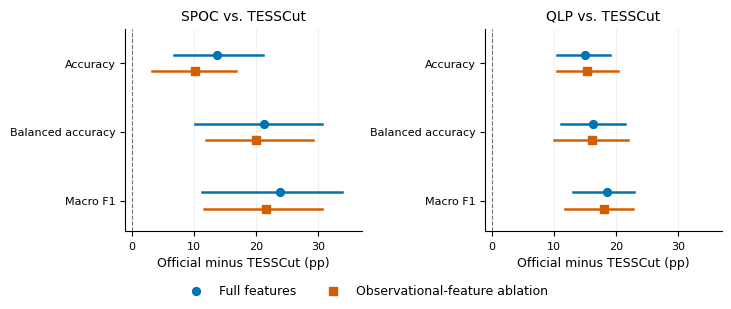

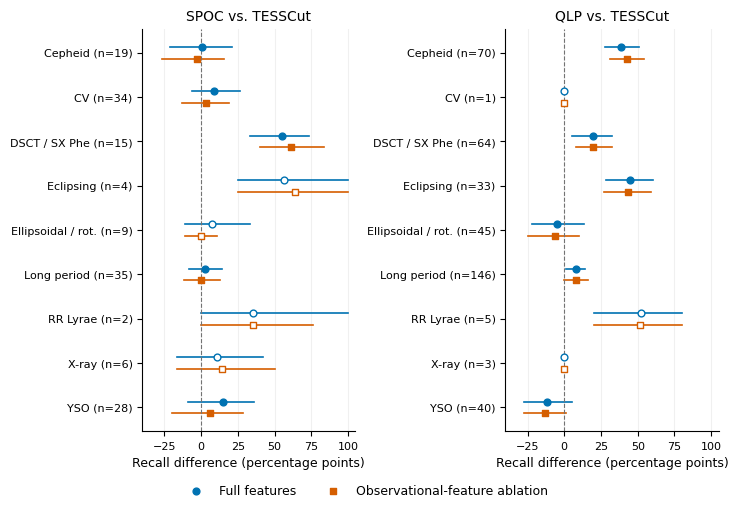

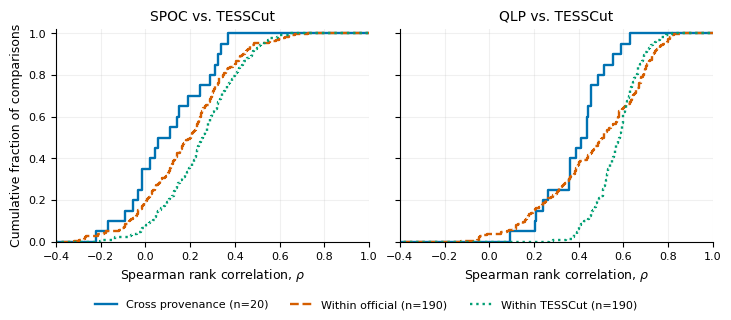

Generated paper figures:
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/figures_output/paired_metric_gaps_output.pdf
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/figures_output/paired_metric_gaps_output.png
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/figures_output/per_class_recall_gaps_output.pdf
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/figures_output/per_class_recall_gaps_output.png
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/figures_output/importance_stability_output.pdf
/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/figures_output/importance_stability_output.png


In [40]:
# Generate the three figures used by the manuscript.
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 9, "axes.titlesize": 10,
    "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "axes.spines.top": False, "axes.spines.right": False,
})
paper_figure_paths = []

figure, axes = plt.subplots(1, 2, figsize=(7.2, 3.0), sharex=True, layout="constrained")
for axis, comparison in zip(axes, PAPER_COMPARISONS):
    for offset_index, (variant, color, marker) in enumerate(zip(
        ["Full features", "Metadata ablation"], PAPER_COLORS, ["o", "s"]
    )):
        selected = paper_aggregate[
            (paper_aggregate["Comparison"] == comparison)
            & (paper_aggregate["Variant"] == variant)
        ]
        for metric_index, (_, row) in enumerate(selected.iterrows()):
            y = 2 - metric_index + (0.12 if offset_index == 0 else -0.12)
            axis.plot([100 * row["DeltaP025"], 100 * row["DeltaP975"]], [y, y], color=color, lw=1.8)
            display_variant = "Observational-feature ablation" if variant == "Metadata ablation" else variant
            axis.scatter(100 * row["DeltaMean"], y, color=color, marker=marker, s=32,
                         label=display_variant if metric_index == 0 else None, zorder=3)
    axis.axvline(0, color="0.45", lw=0.8, ls="--")
    axis.set(yticks=[2, 1, 0], yticklabels=[item[1] for item in PAPER_METRICS],
             ylim=(-0.45, 2.5), xlim=(-1, 37), xlabel="Official minus TESSCut (pp)",
             title=comparison.replace("_vs_", " vs. "))
    axis.grid(axis="x", alpha=0.18)
handles, labels = axes[0].get_legend_handles_labels()
figure.legend(handles, labels, loc="outside lower center", ncol=2, frameon=False)
paper_figure_paths.extend(save_paper_figure(figure, "paired_metric_gaps_output"))

figure, axes = plt.subplots(1, 2, figsize=(7.2, 5.0), sharex=True, layout="constrained")
for axis, comparison in zip(axes, PAPER_COMPARISONS):
    for offset_index, (variant, color, marker) in enumerate(zip(
        ["Full features", "Metadata ablation"], PAPER_COLORS, ["o", "s"]
    )):
        selected = paper_per_class[
            (paper_per_class["Comparison"] == comparison)
            & (paper_per_class["Variant"] == variant)
            & (paper_per_class["Metric"] == "Recall")
        ].set_index("Family")
        for family_index, family in enumerate(PAPER_FAMILIES):
            row = selected.loc[family]
            y = len(PAPER_FAMILIES) - 1 - family_index + (0.13 if offset_index == 0 else -0.13)
            axis.plot([100 * row["DeltaP025"], 100 * row["DeltaP975"]], [y, y], color=color, lw=1.2)
            display_variant = "Observational-feature ablation" if variant == "Metadata ablation" else variant
            axis.scatter(100 * row["DeltaMean"], y,
                         facecolors=color if row["TestSupport"] >= 10 else "white",
                         edgecolors=color, marker=marker, s=24, zorder=3,
                         label=display_variant if family_index == 0 else None)
    labels_for_axis = [
        f"{PAPER_FAMILY_DISPLAY[family]} (n={int(selected.loc[family, 'TestSupport'])})"
        for family in PAPER_FAMILIES
    ]
    axis.set(yticks=list(range(len(PAPER_FAMILIES)))[::-1], yticklabels=labels_for_axis,
             xlabel="Recall difference (percentage points)", xlim=(-40, 105),
             title=comparison.replace("_vs_", " vs. "))
    axis.axvline(0, color="0.45", lw=0.8, ls="--")
    axis.grid(axis="x", alpha=0.18)
handles, labels = axes[0].get_legend_handles_labels()
figure.legend(handles, labels, loc="outside lower center", ncol=2, frameon=False)
paper_figure_paths.extend(save_paper_figure(figure, "per_class_recall_gaps_output"))

figure, axes = plt.subplots(1, 2, figsize=(7.2, 3.1), sharex=True, sharey=True, layout="constrained")
for axis, comparison in zip(axes, PAPER_COMPARISONS):
    official_name = comparison.split("_vs_")[0]
    for correlation_type, color, line_style in zip(
        ["Cross provenance", f"Within {official_name}", "Within TESSCut"],
        PAPER_COLORS, ["-", "--", ":"],
    ):
        values = np.sort(paper_correlations[
            (paper_correlations["Comparison"] == comparison)
            & (paper_correlations["Type"] == correlation_type)
        ]["Rho"].to_numpy())
        label = "Within official" if correlation_type == f"Within {official_name}" else correlation_type
        axis.step(np.r_[-1, values, 1], np.r_[0, np.arange(1, len(values) + 1) / len(values), 1],
                  where="post", color=color, ls=line_style, lw=1.7,
                  label=f"{label} (n={len(values)})")
    axis.set(xlim=(-0.4, 1), ylim=(0, 1.02), xlabel=r"Spearman rank correlation, $\rho$",
             title=comparison.replace("_vs_", " vs. "))
    axis.grid(alpha=0.18)
axes[0].set_ylabel("Cumulative fraction of comparisons")
handles, labels = axes[0].get_legend_handles_labels()
figure.legend(handles, labels, loc="outside lower center", ncol=3, frameon=False, fontsize=8)
paper_figure_paths.extend(save_paper_figure(figure, "importance_stability_output"))

print("Generated paper figures:")
for path in paper_figure_paths:
    print(path)

In [41]:
# Save and verify a traceability manifest for every paper asset.
paper_asset_manifest = {
    "analysis_name": "RASTI paper asset generation",
    "models_refitted": False,
    "source_simulation_manifest": str(manifest_path),
    "source_ablation_manifest": str(ABLATION_MANIFEST_PATH),
    "split_count": int(N_SPLITS),
    "permutation_split_count": int(PERMUTATION_SPLIT_COUNT),
    "full_feature_count": int(len(FULL_FEATURE_COLUMNS)),
    "ablated_feature_count": int(len(ABLATED_FEATURE_COLUMNS)),
    "removed_observational_features": METADATA_LIKE_FEATURES_REMOVED,
    "tables": [str(path) for path in paper_table_paths],
    "figures": [str(path) for path in paper_figure_paths],
    "audit_files": [
        str(PAPER_AUDIT_DIR / "aggregate_metrics_output.csv"),
        str(PAPER_AUDIT_DIR / "per_class_metrics_output.csv"),
        str(PAPER_AUDIT_DIR / "importance_pairwise_correlations_output.csv"),
        str(PAPER_AUDIT_DIR / "importance_correlation_summary_output.csv"),
    ],
}
paper_manifest_path = PAPER_ASSET_ROOT / "paper_asset_manifest.json"
paper_manifest_path.write_text(json.dumps(paper_asset_manifest, indent=2), encoding="utf-8")

expected_table_files = 5
expected_figure_files = 6  # three figures, each in PDF and PNG
assert len(paper_table_paths) == expected_table_files
assert len(paper_figure_paths) == expected_figure_files
assert all(path.exists() and path.stat().st_size > 0 for path in paper_table_paths)
assert all(path.exists() and path.stat().st_size > 0 for path in paper_figure_paths)
assert len(paper_aggregate) == 12
assert len(paper_per_class) == 72
assert len(paper_correlations[paper_correlations["Type"] == "Cross provenance"]) == 40
assert len(paper_correlations[paper_correlations["Type"].str.startswith("Within")]) == 760

print("Paper asset traceability verification passed.")
print(f"Manifest: {paper_manifest_path}")
display(pd.DataFrame({
    "Asset type": ["LaTeX tables", "CSV table equivalents", "PDF figures", "PNG figures"],
    "Count": [5, 5, 3, 3],
}))

Paper asset traceability verification passed.
Manifest: /data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/paper_asset_manifest.json


,Asset type,Count
0,LaTeX tables,5
1,CSV table equivalents,5
2,PDF figures,3
3,PNG figures,3


## 12. Direct regeneration of paper Figures 5, 7, 8, 9, and 10

This section regenerates the five manuscript figures that depend on the matched-star analyses from saved Monte Carlo and ablation results. It does not fit Random Forest models, recompute permutation importance, or rerun the simulations.

- **Figure 5:** seed-42 SPOC–TESSCut impurity-importance rank shifts.
- **Figure 7:** seed-42 QLP–TESSCut impurity-importance rank shifts.
- **Figure 8:** repeated aggregate metric gaps before and after observational-feature ablation.
- **Figure 9:** repeated per-class recall gaps.
- **Figure 10:** cross- and within-provenance permutation-importance rank stability.

Figures 5 and 7 use split seed 42, the representative single split used by the controlled analysis. Figures 8–10 summarize the repeated saved results. The required saved result objects are loaded by the preceding bypass-mode sections.


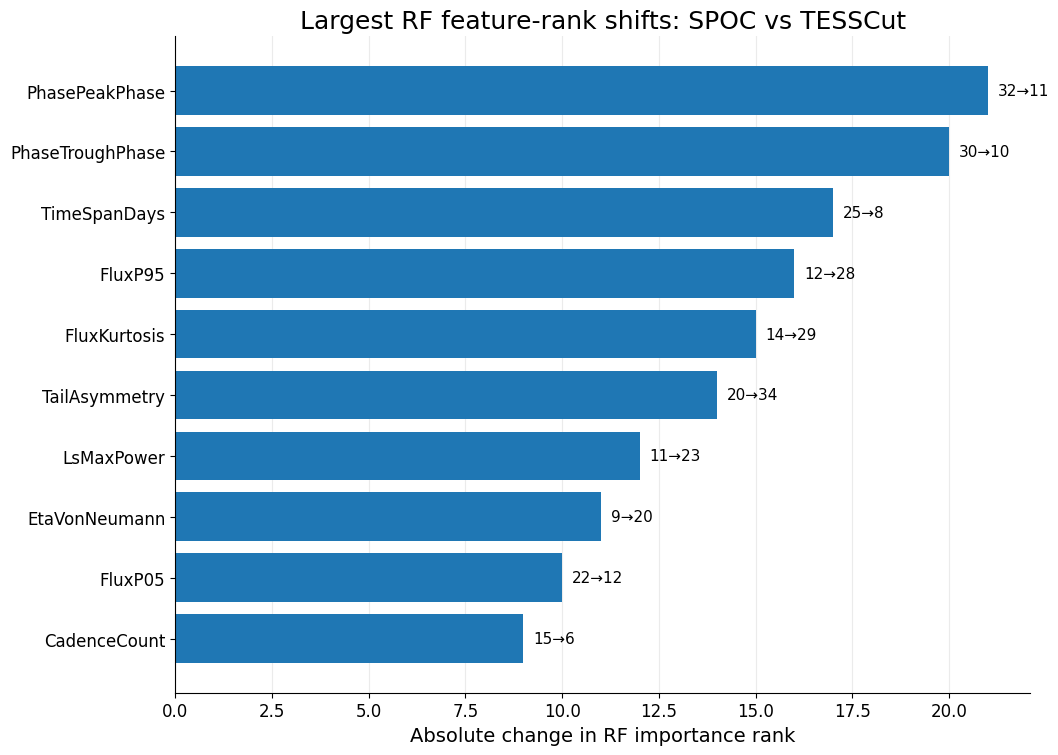

Generated from saved seed-42 importance values: /data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/spoc_tesscut_rf_rank_shifts.png


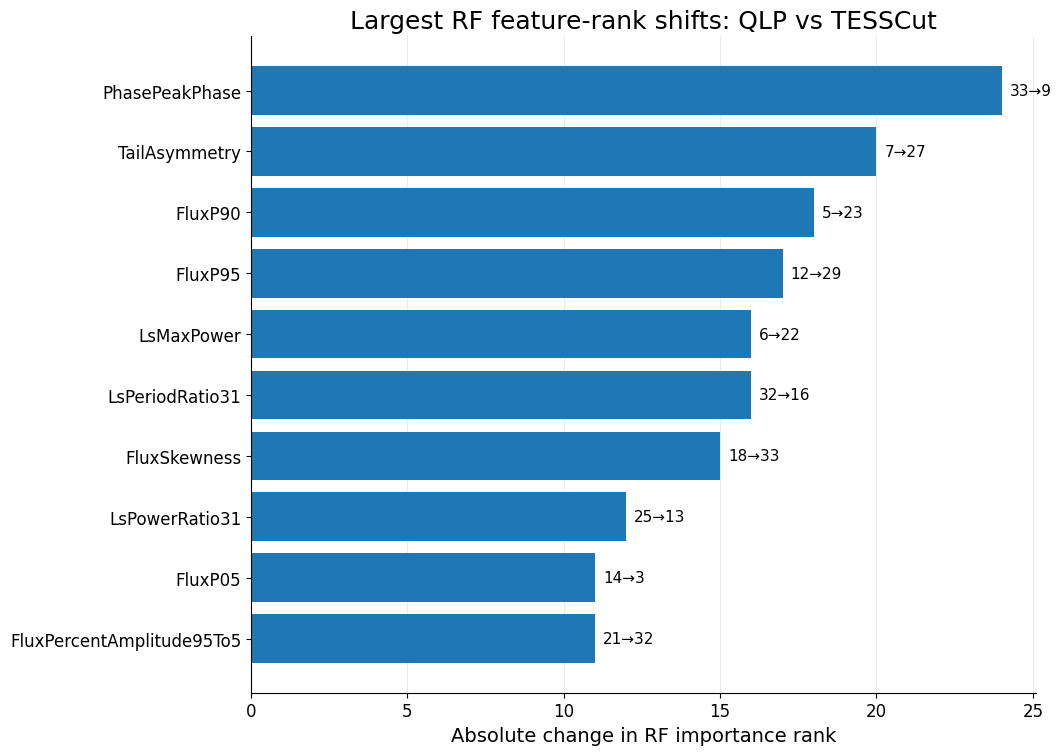

Generated from saved seed-42 importance values: /data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/qlp_tesscut_rf_rank_shifts.png


,Feature,SPOCRFImportance,TESSCutRFImportance,SPOCRank,TESSCutRank,AbsRankChange
0,PhasePeakPhase,0.011015,0.032374,32.0,11.0,21.0
1,PhaseTroughPhase,0.013749,0.032876,30.0,10.0,20.0
2,TimeSpanDays,0.017604,0.034077,25.0,8.0,17.0
3,FluxP95,0.031411,0.022039,12.0,28.0,16.0
4,FluxKurtosis,0.029125,0.021429,14.0,29.0,15.0
5,TailAsymmetry,0.022741,0.018165,20.0,34.0,14.0
6,LsMaxPower,0.034264,0.024191,11.0,23.0,12.0
7,EtaVonNeumann,0.036641,0.027016,9.0,20.0,11.0
8,FluxP05,0.019982,0.031170,22.0,12.0,10.0
9,CadenceCount,0.026760,0.037673,15.0,6.0,9.0


,Feature,QLPRFImportance,TESSCutRFImportance,QLPRank,TESSCutRank,AbsRankChange
0,PhasePeakPhase,0.015295,0.032447,33.0,9.0,24.0
1,TailAsymmetry,0.039206,0.022693,7.0,27.0,20.0
2,FluxP90,0.044570,0.025023,5.0,23.0,18.0
3,FluxP95,0.036033,0.021683,12.0,29.0,17.0
4,LsMaxPower,0.041953,0.025277,6.0,22.0,16.0
5,LsPeriodRatio31,0.015820,0.027887,32.0,16.0,16.0
6,FluxSkewness,0.022701,0.019533,18.0,33.0,15.0
7,LsPowerRatio31,0.019188,0.029508,25.0,13.0,12.0
8,FluxP05,0.026672,0.044849,14.0,3.0,11.0
9,FluxPercentAmplitude95To5,0.021853,0.020766,21.0,32.0,11.0


In [42]:
# Figures 5 and 7: representative single-split RF impurity-importance rank shifts.
# Source: saved monte_carlo_rf_feature_importance.parquet, split seed 42.
REPRESENTATIVE_SPLIT_SEED = 42
representative_rf_importance = combined_results["rf_importance"].copy()

required_importance_columns = {
    "Comparison", "SplitSeed", "Provenance", "Feature", "RFImportance"
}
missing_importance_columns = sorted(
    required_importance_columns - set(representative_rf_importance.columns)
)
if missing_importance_columns:
    raise KeyError(
        f"Saved RF-importance output is missing: {missing_importance_columns}"
    )

def build_representative_rank_shift(comparison, official_provenance):
    saved = representative_rf_importance[
        (representative_rf_importance["Comparison"] == comparison)
        & (representative_rf_importance["SplitSeed"] == REPRESENTATIVE_SPLIT_SEED)
    ].copy()
    official = saved[saved["Provenance"] == official_provenance][
        ["Feature", "RFImportance"]
    ].rename(columns={"RFImportance": f"{official_provenance}RFImportance"})
    tesscut = saved[saved["Provenance"] == "TESSCut"][
        ["Feature", "RFImportance"]
    ].rename(columns={"RFImportance": "TESSCutRFImportance"})
    rank_shift = official.merge(tesscut, on="Feature", validate="one_to_one")
    if len(rank_shift) != len(FULL_FEATURE_COLUMNS):
        raise AssertionError(
            f"Expected {len(FULL_FEATURE_COLUMNS)} features for {comparison}; "
            f"found {len(rank_shift)}."
        )
    rank_shift[f"{official_provenance}Rank"] = rank_shift[
        f"{official_provenance}RFImportance"
    ].rank(method="min", ascending=False)
    rank_shift["TESSCutRank"] = rank_shift["TESSCutRFImportance"].rank(
        method="min", ascending=False
    )
    rank_shift["AbsRankChange"] = (
        rank_shift[f"{official_provenance}Rank"] - rank_shift["TESSCutRank"]
    ).abs()
    return rank_shift.sort_values(
        ["AbsRankChange", f"{official_provenance}RFImportance"],
        ascending=[False, False],
    ).reset_index(drop=True)

def plot_representative_rank_shift(comparison, official_provenance, filename):
    rank_shift = build_representative_rank_shift(comparison, official_provenance)
    top_ten = rank_shift.head(10).iloc[::-1].copy()
    figure, axis = plt.subplots(figsize=(10.67, 7.63))
    bars = axis.barh(top_ten["Feature"], top_ten["AbsRankChange"], color="#1f77b4")
    official_rank_column = f"{official_provenance}Rank"
    for bar, (_, row) in zip(bars, top_ten.iterrows()):
        label = f"{int(row[official_rank_column])}→{int(row['TESSCutRank'])}"
        axis.text(
            bar.get_width() + 0.25, bar.get_y() + bar.get_height() / 2,
            label, va="center", fontsize=11,
        )
    axis.set_title(
        f"Largest RF feature-rank shifts: {official_provenance} vs TESSCut",
        fontsize=18,
    )
    axis.set_xlabel("Absolute change in RF importance rank", fontsize=14)
    axis.tick_params(axis="both", labelsize=12)
    axis.grid(axis="x", alpha=0.25)
    axis.set_axisbelow(True)
    axis.set_xlim(0, top_ten["AbsRankChange"].max() + 1.1)
    figure.tight_layout()
    output_path = PAPER_ASSET_ROOT / filename
    figure.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(figure)
    print(f"Generated from saved seed-42 importance values: {output_path}")
    return output_path, rank_shift

figure_5_path, figure_5_rank_data = plot_representative_rank_shift(
    "SPOC_vs_TESSCut", "SPOC", "spoc_tesscut_rf_rank_shifts.png"
)
figure_7_path, figure_7_rank_data = plot_representative_rank_shift(
    "QLP_vs_TESSCut", "QLP", "qlp_tesscut_rf_rank_shifts.png"
)
display(figure_5_rank_data.head(10))
display(figure_7_rank_data.head(10))

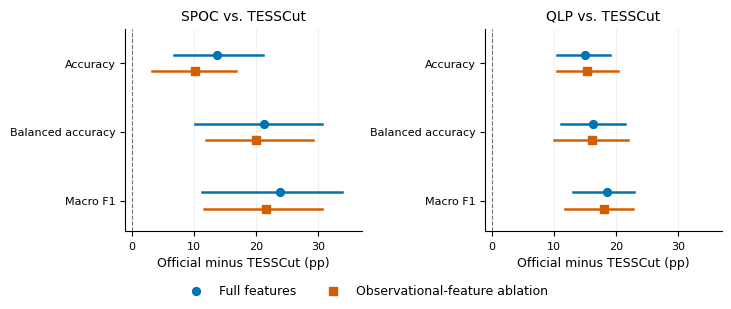

Figure 8 regenerated from saved aggregate summaries: (PosixPath('/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/figures_output/paired_metric_gaps_output.pdf'), PosixPath('/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/figures_output/paired_metric_gaps_output.png'))


In [43]:
# Figure 8: paired aggregate performance gaps over 100 saved splits.
figure, axes = plt.subplots(1, 2, figsize=(7.2, 3.0), sharex=True, layout="constrained")
for axis, comparison in zip(axes, PAPER_COMPARISONS):
    for offset_index, (variant, color, marker) in enumerate(zip(
        ["Full features", "Metadata ablation"], PAPER_COLORS, ["o", "s"]
    )):
        selected = paper_aggregate[
            (paper_aggregate["Comparison"] == comparison)
            & (paper_aggregate["Variant"] == variant)
        ]
        for metric_index, (_, row) in enumerate(selected.iterrows()):
            y = 2 - metric_index + (0.12 if offset_index == 0 else -0.12)
            axis.plot(
                [100 * row["DeltaP025"], 100 * row["DeltaP975"]],
                [y, y], color=color, lw=1.8,
            )
            display_variant = (
                "Observational-feature ablation"
                if variant == "Metadata ablation" else variant
            )
            axis.scatter(
                100 * row["DeltaMean"], y, color=color, marker=marker, s=32,
                label=display_variant if metric_index == 0 else None, zorder=3,
            )
    axis.axvline(0, color="0.45", lw=0.8, ls="--")
    axis.set(
        yticks=[2, 1, 0], yticklabels=[item[1] for item in PAPER_METRICS],
        ylim=(-0.45, 2.5), xlim=(-1, 37),
        xlabel="Official minus TESSCut (pp)",
        title=comparison.replace("_vs_", " vs. "),
    )
    axis.grid(axis="x", alpha=0.18)
handles, labels = axes[0].get_legend_handles_labels()
figure.legend(handles, labels, loc="outside lower center", ncol=2, frameon=False)
figure_8_paths = save_paper_figure(figure, "paired_metric_gaps_output")
print(f"Figure 8 regenerated from saved aggregate summaries: {figure_8_paths}")

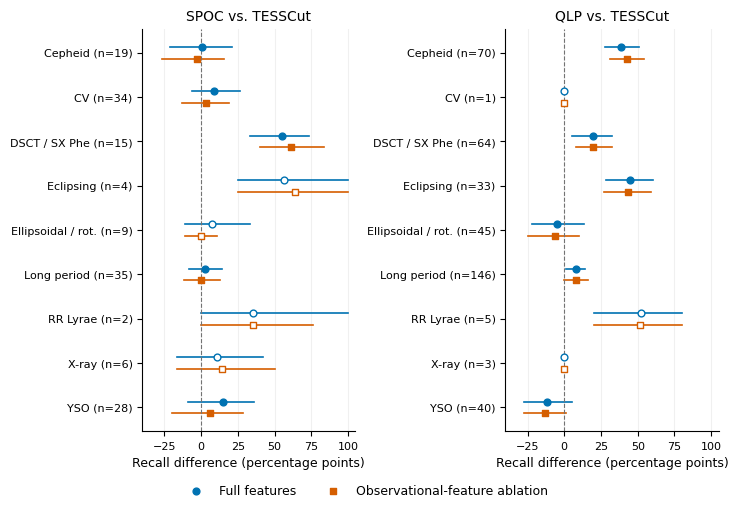

Figure 9 regenerated from saved per-class summaries: (PosixPath('/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/figures_output/per_class_recall_gaps_output.pdf'), PosixPath('/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/figures_output/per_class_recall_gaps_output.png'))


In [44]:
# Figure 9: per-class recall differences over 100 saved splits.
figure, axes = plt.subplots(1, 2, figsize=(7.2, 5.0), sharex=True, layout="constrained")
for axis, comparison in zip(axes, PAPER_COMPARISONS):
    label_source = None
    for offset_index, (variant, color, marker) in enumerate(zip(
        ["Full features", "Metadata ablation"], PAPER_COLORS, ["o", "s"]
    )):
        selected = paper_per_class[
            (paper_per_class["Comparison"] == comparison)
            & (paper_per_class["Variant"] == variant)
            & (paper_per_class["Metric"] == "Recall")
        ].set_index("Family")
        label_source = selected
        for family_index, family in enumerate(PAPER_FAMILIES):
            row = selected.loc[family]
            y = len(PAPER_FAMILIES) - 1 - family_index + (
                0.13 if offset_index == 0 else -0.13
            )
            axis.plot(
                [100 * row["DeltaP025"], 100 * row["DeltaP975"]],
                [y, y], color=color, lw=1.2,
            )
            display_variant = (
                "Observational-feature ablation"
                if variant == "Metadata ablation" else variant
            )
            axis.scatter(
                100 * row["DeltaMean"], y,
                facecolors=color if row["TestSupport"] >= 10 else "white",
                edgecolors=color, marker=marker, s=24, zorder=3,
                label=display_variant if family_index == 0 else None,
            )
    labels_for_axis = [
        f"{PAPER_FAMILY_DISPLAY[family]} (n={int(label_source.loc[family, 'TestSupport'])})"
        for family in PAPER_FAMILIES
    ]
    axis.set(
        yticks=list(range(len(PAPER_FAMILIES)))[::-1],
        yticklabels=labels_for_axis,
        xlabel="Recall difference (percentage points)",
        xlim=(-40, 105), title=comparison.replace("_vs_", " vs. "),
    )
    axis.axvline(0, color="0.45", lw=0.8, ls="--")
    axis.grid(axis="x", alpha=0.18)
handles, labels = axes[0].get_legend_handles_labels()
figure.legend(handles, labels, loc="outside lower center", ncol=2, frameon=False)
figure_9_paths = save_paper_figure(figure, "per_class_recall_gaps_output")
print(f"Figure 9 regenerated from saved per-class summaries: {figure_9_paths}")

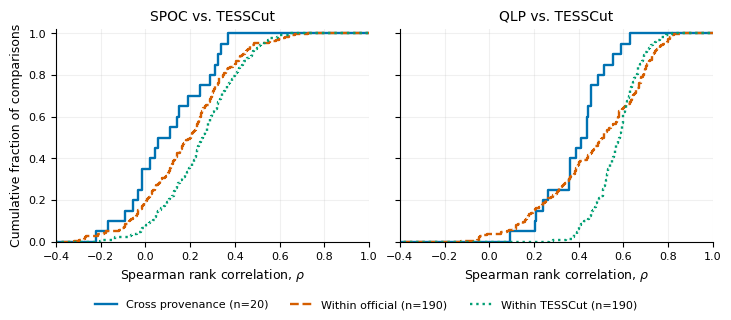

Figure 10 regenerated from saved rank correlations: (PosixPath('/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/figures_output/importance_stability_output.pdf'), PosixPath('/data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/figures_output/importance_stability_output.png'))


In [45]:
# Figure 10: empirical distributions of saved importance-rank correlations.
figure, axes = plt.subplots(1, 2, figsize=(7.2, 3.1), sharex=True, sharey=True, layout="constrained")
for axis, comparison in zip(axes, PAPER_COMPARISONS):
    official_name = comparison.split("_vs_")[0]
    for correlation_type, color, line_style in zip(
        ["Cross provenance", f"Within {official_name}", "Within TESSCut"],
        PAPER_COLORS, ["-", "--", ":"],
    ):
        values = np.sort(paper_correlations[
            (paper_correlations["Comparison"] == comparison)
            & (paper_correlations["Type"] == correlation_type)
        ]["Rho"].to_numpy())
        if len(values) == 0:
            raise AssertionError(f"No saved correlations for {comparison}, {correlation_type}.")
        label = (
            "Within official"
            if correlation_type == f"Within {official_name}" else correlation_type
        )
        axis.step(
            np.r_[-1, values, 1],
            np.r_[0, np.arange(1, len(values) + 1) / len(values), 1],
            where="post", color=color, ls=line_style, lw=1.7,
            label=f"{label} (n={len(values)})",
        )
    axis.set(
        xlim=(-0.4, 1), ylim=(0, 1.02),
        xlabel=r"Spearman rank correlation, $\rho$",
        title=comparison.replace("_vs_", " vs. "),
    )
    axis.grid(alpha=0.18)
axes[0].set_ylabel("Cumulative fraction of comparisons")
handles, labels = axes[0].get_legend_handles_labels()
figure.legend(
    handles, labels, loc="outside lower center", ncol=3,
    frameon=False, fontsize=8,
)
figure_10_paths = save_paper_figure(figure, "importance_stability_output")
print(f"Figure 10 regenerated from saved rank correlations: {figure_10_paths}")

In [46]:
# Verify and record the exact saved-result source for each regenerated figure.
paper_figure_traceability = pd.DataFrame([
    {"PaperFigure": 5, "Output": str(figure_5_path),
     "SavedSource": str(output_files["rf_importance"]),
     "Selection": "SPOC_vs_TESSCut, SplitSeed=42, RFImportance"},
    {"PaperFigure": 7, "Output": str(figure_7_path),
     "SavedSource": str(output_files["rf_importance"]),
     "Selection": "QLP_vs_TESSCut, SplitSeed=42, RFImportance"},
    {"PaperFigure": 8, "Output": str(figure_8_paths[0]),
     "SavedSource": "full and ablated paired-split summaries",
     "Selection": "100 paired splits, aggregate metrics"},
    {"PaperFigure": 9, "Output": str(figure_9_paths[0]),
     "SavedSource": "full and ablated family test metrics",
     "Selection": "100 paired splits, class recall"},
    {"PaperFigure": 10, "Output": str(figure_10_paths[0]),
     "SavedSource": str(output_files["permutation_importance_summary"]),
     "Selection": "20 selected splits; cross/within rank correlations"},
])
traceability_path = PAPER_AUDIT_DIR / "paper_figure_traceability_output.csv"
paper_figure_traceability.to_csv(traceability_path, index=False)
figure_files = [
    figure_5_path, figure_7_path, *figure_8_paths, *figure_9_paths, *figure_10_paths
]
assert all(path.exists() and path.stat().st_size > 0 for path in figure_files)
assert len(figure_5_rank_data) == len(FULL_FEATURE_COLUMNS)
assert len(figure_7_rank_data) == len(FULL_FEATURE_COLUMNS)
print("Figures 5, 7, 8, 9, and 10 regenerated without model fitting.")
print(f"Traceability table: {traceability_path}")
display(paper_figure_traceability)

Figures 5, 7, 8, 9, and 10 regenerated without model fitting.
Traceability table: /data/projects/TESS-research/summary/controlled_analysis_monte_carlo_v2/paper_assets_output/analysis_output/paper_figure_traceability_output.csv


,PaperFigure,Output,SavedSource,Selection
0,5,/data/projects/TESS-research/summary/controlle...,/data/projects/TESS-research/summary/controlle...,"SPOC_vs_TESSCut, SplitSeed=42, RFImportance"
1,7,/data/projects/TESS-research/summary/controlle...,/data/projects/TESS-research/summary/controlle...,"QLP_vs_TESSCut, SplitSeed=42, RFImportance"
2,8,/data/projects/TESS-research/summary/controlle...,full and ablated paired-split summaries,"100 paired splits, aggregate metrics"
3,9,/data/projects/TESS-research/summary/controlle...,full and ablated family test metrics,"100 paired splits, class recall"
4,10,/data/projects/TESS-research/summary/controlle...,/data/projects/TESS-research/summary/controlle...,20 selected splits; cross/within rank correlat...
